# Step 1: Download raw data (Munich, 2017 & 2023)

# Munich raw downloads (2017 vs 2023)
Goal: download historical OSM layers for Munich to support bikeability factors:
- Road Class (all roads w/ tags)
- Main Road Separation (cycleway=track/segregated etc.)
- Road Surface (surface=*)
- Cycling Network (route=bicycle relations + member ways)
- Topography

Outputs: a single GeoPackage with layers per year (2017, 2023).
Optional: download a DEM (for Topography factor).


> Notes
> - Overpass supports **historical queries** via `date:` — we’ll use mid-year snapshots: **2017-06-30** and **2023-06-30**.
> - Output is saved as a single **GeoPackage** with multiple layers, plus helper CSVs/GeoJSONs.



In [1]:

%pip install geopandas shapely pyproj requests tenacity osmnx fiona rtree pyogrio --quiet


Note: you may need to restart the kernel to use updated packages.


In [16]:
%cd "C:/Users/Valeria/OneDrive/Рабочий стол/Thesis/src"



C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\src


In [18]:
# --- Load the base Thesis path from config.yml ---
import yaml
from pathlib import Path

# Notebook is in Thesis/src → go up one level to Thesis/
ROOT = Path().resolve().parent

# Load config.yml from Thesis root
CONFIG_PATH = ROOT / "config.yml"
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# THESIS_PATH is the project root (from the config)
# config.yml:
# THESIS_PATH: 'C:/Users/Valeria/OneDrive/Рабочий стол/Thesis'
THESIS_PATH = Path(cfg["THESIS_PATH"])

# --- Define data directories based on the project structure ---
DATA_DIR        = THESIS_PATH / "Data"
RAW_DIR         = DATA_DIR / "00_raw_data" / "Munich"
PROCESSED_DIR   = DATA_DIR / "01_processed_data"

# Ensure processed folder exists
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Define output path for the GeoPackage
GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

# --- OSMnx settings ---
import osmnx as ox
ox.settings.use_cache = True
ox.settings.log_console = True

# --- Other constants ---
CITY_NAME = "Munich, Bavaria, Germany"
YEAR_SNAPSHOTS = {
    "2017": "2017-06-30T00:00:00Z",
    "2023": "2023-06-30T00:00:00Z"
}
OVERPASS_URL = "https://overpass-api.de/api/interpreter"

# --- Sanity check ---
print("Loaded config from:", CONFIG_PATH)
print("Thesis base path:", THESIS_PATH)
print("Data directory:", DATA_DIR)
print("Raw data directory:", RAW_DIR)
print("Processed data directory:", PROCESSED_DIR)
print("Outputs will go to:", GPKG.resolve())


Loaded config from: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\config.yml
Thesis base path: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis
Data directory: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data
Raw data directory: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich
Processed data directory: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\01_processed_data
Outputs will go to: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\munich_bikeability_raw.gpkg


In [19]:
import os, sys
from pathlib import Path

# Try typical conda-forge locations for PROJ data
proj_dir_candidates = [
    Path(sys.prefix) / "Library" / "share" / "proj",  # Windows (Anaconda/Miniconda)
    Path(sys.prefix) / "share" / "proj",              # Linux/macOS
]

for p in proj_dir_candidates:
    if p.exists():
        os.environ["PROJ_LIB"] = str(p)
        break

# (Optional) tell pyproj explicitly
try:
    import pyproj
    from pyproj import datadir
    if "PROJ_LIB" in os.environ:
        pyproj.datadir.set_data_dir(os.environ["PROJ_LIB"])
    print("pyproj version:", pyproj.__version__)
    print("Using PROJ data dir:", datadir.get_data_dir())
except Exception as e:
    print("pyproj not importable:", e)

# (Optional) set OSMnx default CRS (not required, but explicit)
import osmnx as ox
ox.settings.default_crs = "EPSG:4326"


pyproj version: 3.7.2
Using PROJ data dir: C:\Users\Valeria\anaconda3\envs\geo-env\Library\share\proj


In [20]:
# Fetch Munich administrative/municipal boundary polygon from OSM (via Nominatim through osmnx)
gdf_place = ox.geocode_to_gdf(CITY_NAME)
if gdf_place.empty:
    raise RuntimeError("Could not geocode city boundary for: %s" % CITY_NAME)

# Use the largest polygon geometry (in case of multipolygons)
geom = gdf_place.loc[gdf_place.geometry.area.idxmax()].geometry
if geom.type == "Polygon":
    munich_poly = geom
elif geom.type == "MultiPolygon":
    munich_poly = max(geom.geoms, key=lambda g: g.area)   # Overpass polygon filters expect a polygon ring
else:
    raise RuntimeError(f"Unexpected geometry type: {geom.type}")

munich_boundary = gpd.GeoDataFrame({'name':[CITY_NAME]}, geometry=[munich_poly], crs="EPSG:4326")
munich_boundary.to_file(GPKG, layer="munich_boundary", driver="GPKG")   # Persist boundary for reference

munich_bbox = munich_boundary.total_bounds  # [minx, miny, maxx, maxy]
print("Boundary & bbox saved.", munich_bbox)

Boundary & bbox saved. [11.360777  48.0616244 11.7229099 48.2481162]


C:\Users\Valeria\AppData\Local\Temp\ipykernel_21092\6487427.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = gdf_place.loc[gdf_place.geometry.area.idxmax()].geometry
C:\Users\Valeria\AppData\Local\Temp\ipykernel_21092\6487427.py:8: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom.type == "Polygon":
C:\Users\Valeria\AppData\Local\Temp\ipykernel_21092\6487427.py:10: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  elif geom.type == "MultiPolygon":


Returned features: 1


,display_name,type,geometry
0,"Munich, Bavaria, Germany",administrative,"MULTIPOLYGON (((11.36078 48.15807, 11.36085 48..."


C:\Users\Valeria\AppData\Local\Temp\ipykernel_21092\3476629826.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_place.centroid.plot(ax=ax, color="red", markersize=20)


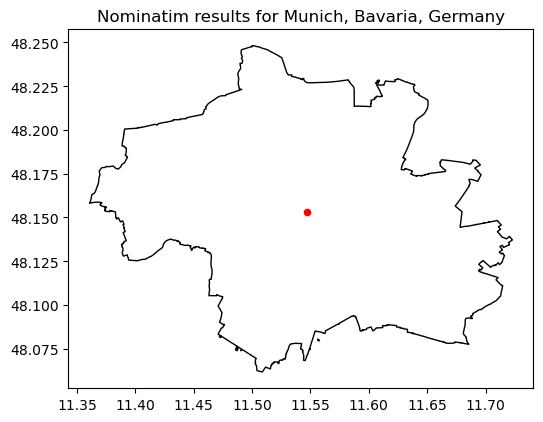

In [21]:
# Inspect the geocoding result before choosing the largest polygon
import matplotlib.pyplot as plt

print("Returned features:", len(gdf_place))
display(gdf_place[["display_name", "type", "geometry"]])

# Optional quick map
ax = gdf_place.plot(edgecolor="black", facecolor="none", figsize=(6,6))
gdf_place.centroid.plot(ax=ax, color="red", markersize=20)
plt.title(f"Nominatim results for {CITY_NAME}")
plt.show()

In [22]:
# Overpass helpers (polygon → string, robust POST)

def poly_to_overpass_coords(poly: Polygon) -> str:    # Convert a Polygon exterior to Overpass 'poly:"lat lon ..."' string (WGS84)
    # Overpass expects lat lon pairs; poly exterior coords are lon,lat
    coords = list(poly.exterior.coords)
    # format: lat lon for Overpass 'poly:"lat lon lat lon ..."'
    latlon = " ".join([f"{y} {x}" for x,y in coords])
    return latlon

munich_poly_str = poly_to_overpass_coords(munich_poly)

class OverpassError(Exception):
    pass

@retry(reraise=True, stop=stop_after_attempt(5), wait=wait_exponential(multiplier=1, min=1, max=60),   # POST a query to Overpass with retries + basic error checks
       retry=retry_if_exception_type((requests.HTTPError, requests.ConnectionError, requests.Timeout, OverpassError)))
def overpass(query: str, *, timeout=300) -> dict:
    resp = requests.post(OVERPASS_URL, data={'data': query}, timeout=timeout)
    if resp.status_code != 200:
        raise OverpassError(f"Overpass HTTP {resp.status_code}: {resp.text[:200]}...")
    try:
        return resp.json()
    except Exception as e:
        # Overpass sometimes returns text errors
        raise OverpassError(f"Non-JSON response: {resp.text[:200]}...")

In [23]:
# Convert Overpass JSON → GeoDataF

from shapely.geometry import LineString, Point

def overpass_to_gdf(data: dict, *, as_lines=True, keep_tags=None, crs="EPSG:4326") -> gpd.GeoDataFrame:     # Build a LineString GeoDataFrame from ways + nodes
    elements = data.get('elements', [])                                                                     # Optionally return a non-geometry table for relations (tags only)
    nodes = {el['id']: (el['lat'], el['lon']) for el in elements if el['type'] == 'node'}
    feats = []
    for el in elements:
        if el['type'] == 'way':
            coords = [(nodes[nid][1], nodes[nid][0]) for nid in el.get('nodes', []) if nid in nodes]
            if len(coords) >= 2:
                geom = LineString(coords)
                props = el.get('tags', {}).copy()
                props['osmid'] = el['id']
                if keep_tags:
                    props = {k: props.get(k) for k in keep_tags if k in props}
                feats.append({"geometry": geom, **props})
        elif el['type'] == 'relation' and not as_lines:
            # If we choose to keep relations (for routes), store basic tag set; geometry is not trivial w/o ways.
            props = el.get('tags', {}).copy()
            props['osmid'] = el['id']
            feats.append({"geometry": None, **props})
    if not feats:
        return gpd.GeoDataFrame(columns=(keep_tags or []) + ['osmid','geometry'], geometry='geometry', crs=crs)
    gdf = gpd.GeoDataFrame(feats, geometry='geometry', crs=crs)
    return gdf

In [24]:
# Query builders (roads, separation, surface, routes)

def build_roads_query(date_iso: str, poly_str: str) -> str:     #   All 'highway' ways (incl. cycleway, path/footway etc.) within polygon at a historical date
    # General road classes, include cycleway & path so we can keep them in one network dump
    highway_vals = [
        'motorway','trunk','primary','secondary','tertiary','unclassified','residential','living_street','service',
        'cycleway','path','track','footway','pedestrian'
    ]
    hv = '|'.join(highway_vals)
    return f"""
[out:json][timeout:300][date:"{date_iso}"];
way["highway"~"^{hv}$"](poly:"{poly_str}");
(._;>;);
out body;
"""

def build_main_road_separation_query(date_iso: str, poly_str: str) -> str:
    # Proxy: roads (not standalone cycleway) with cycleway=track|opposite_track|separate OR segregated=yes
    return f"""
[out:json][timeout:300][date:"{date_iso}"];
way["highway"]["highway"!="cycleway"][~"^cycleway$"~"^(track|opposite_track|separate)$"]
   (poly:"{poly_str}");
way["highway"]["highway"!="cycleway"]["segregated"="yes"](poly:"{poly_str}");
(._;>;);
out body;
"""

def build_surface_query(date_iso: str, poly_str: str) -> str:     #   Ways that carry a 'surface=*' tag within polygon at date
    return f"""
[out:json][timeout:300][date:"{date_iso}"];
way["highway"]["surface"](poly:"{poly_str}");
(._;>;);
out body;
"""

def build_cycle_routes_query(date_iso: str, poly_str: str) -> str:
    # Relations for signed bicycle routes (local/regional/national); will also fetch member ways next
    return f"""
[out:json][timeout:300][date:"{date_iso}"];
rel["route"="bicycle"](poly:"{poly_str}");
out ids tags;
"""

def build_cycle_route_member_ways_query(date_iso: str, relation_ids: list, poly_str: str) -> str:    #  Resolve relation IDs to their member ways (with tags), including node skeleton for geometry
    if not relation_ids: return None
    ids = ','.join(map(str, relation_ids))
    return f"""
[out:json][timeout:300][date:"{date_iso}"];
way(r:{ids})(poly:"{poly_str}");
(._;>;);
out body;
"""

Here I download the data for the four factors

In [25]:
# Write helper + main download loop (2017 & 2023)

def save_layer(gdf, layer):    # Save a GeoDataFrame to the GeoPackage, guarding empty inputs
    if gdf is None or gdf.empty:
        print(f"[warn] Empty layer: {layer}")
        return

    cols = {c: c[:60] for c in gdf.columns}   #  Keep column names short to avoid GPKG 64-char limit (safe at 60)
    gdf = gdf.rename(columns=cols)
    gdf.to_file(GPKG, layer=layer, driver="GPKG")
    print("Saved", layer, len(gdf))

# Tags to keep in outputs
keep_tags_roads = ["highway","name","maxspeed","oneway","bicycle","cycleway","segregated","lanes","junction"]
keep_tags_surface = ["highway","name","surface"]
keep_tags_routes = ["route","network","ref","name"]

for year, date_iso in YEAR_SNAPSHOTS.items():
    print("\n=== Year:", year, date_iso, "===")
    # Roads (by class)
    q_roads = build_roads_query(date_iso, munich_poly_str)
    data_roads = overpass(q_roads)
    gdf_roads = overpass_to_gdf(data_roads, keep_tags=keep_tags_roads)
    save_layer(gdf_roads, f"{year}_roads_all")

    # Main road separation (proxies on roads)
    q_sep = build_main_road_separation_query(date_iso, munich_poly_str)
    data_sep = overpass(q_sep)
    gdf_sep = overpass_to_gdf(data_sep, keep_tags=keep_tags_roads)
    save_layer(gdf_sep, f"{year}_main_road_separation")

    # Surface
    q_surf = build_surface_query(date_iso, munich_poly_str)
    data_surf = overpass(q_surf)
    gdf_surf = overpass_to_gdf(data_surf, keep_tags=keep_tags_surface)
    save_layer(gdf_surf, f"{year}_road_surface")

    # Cycling network (routes and member ways)
    q_routes = build_cycle_routes_query(date_iso, munich_poly_str)
    data_routes = overpass(q_routes)
    rel_ids = [el['id'] for el in data_routes.get('elements', []) if el.get('type') == 'relation']
    # store relations as a flat table (no geometry)
    routes_rows = []
    for el in data_routes.get('elements', []):
        if el['type'] == 'relation':
            row = {"osmid": el['id']}
            row.update(el.get('tags', {}))
            routes_rows.append(row)
    gdf_routes = gpd.GeoDataFrame(routes_rows, geometry=[None]*len(routes_rows), crs="EPSG:4326")
    save_layer(gdf_routes, f"{year}_cycle_routes_relations")

# Batch relation member queries if many IDs (Overpass limits)
    if rel_ids:
        q_route_ways = build_cycle_route_member_ways_query(date_iso, rel_ids, munich_poly_str)
        if q_route_ways:
            data_route_ways = overpass(q_route_ways)
            gdf_route_ways = overpass_to_gdf(data_route_ways, keep_tags=keep_tags_roads)
            # add a helper field indicating they’re part of a route (we could also join by relation memberships later)
            if not gdf_route_ways.empty:
                gdf_route_ways["in_cycle_route"] = True
            save_layer(gdf_route_ways, f"{year}_cycle_routes_member_ways")

print("\nAll requested layers saved to:", GPKG)


=== Year: 2017 2017-06-30T00:00:00Z ===
Saved 2017_roads_all 86127
Saved 2017_main_road_separation 1385
Saved 2017_road_surface 25438
Saved 2017_cycle_routes_relations 88
[warn] Empty layer: 2017_cycle_routes_member_ways

=== Year: 2023 2023-06-30T00:00:00Z ===
Saved 2023_roads_all 110387
Saved 2023_main_road_separation 4106
Saved 2023_road_surface 76385
Saved 2023_cycle_routes_relations 102
[warn] Empty layer: 2023_cycle_routes_member_ways

All requested layers saved to: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\munich_bikeability_raw.gpkg


In [27]:
# A visualization in a table

import yaml
from pathlib import Path
import geopandas as gpd

# Load config (only once per notebook)
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# Get the Thesis base path from config
THESIS_PATH = Path(cfg["THESIS_PATH"])

# Build the full path to the GeoPackage
GPKG = THESIS_PATH / "Data" / "00_raw_data" / "Munich" / "munich_bikeability_raw.gpkg"

# Read the 2023 layer
gdf_2023 = gpd.read_file(GPKG, layer="2023_roads_all")

# Inspect
gdf_2023.head()



,highway,maxspeed,oneway,lanes,name,bicycle,cycleway,segregated,junction,geometry
0,motorway,none,yes,4,None,None,None,None,None,"LINESTRING (11.54134 48.22607, 11.54283 48.22619)"
1,residential,30,None,None,Berberichweg,None,None,None,None,"LINESTRING (11.42324 48.15539, 11.42304 48.1557)"
2,residential,30,None,None,Otto-Klemperer-Weg,None,None,None,None,"LINESTRING (11.42269 48.1556, 11.42241 48.15602)"
3,residential,30,None,None,Feldmeierbogen,None,None,None,None,"LINESTRING (11.42248 48.15714, 11.42201 48.157..."
4,secondary,50,None,None,Altostraße,None,None,None,None,"LINESTRING (11.40823 48.17544, 11.40821 48.175..."


Next I will download the data separately for topography

In [28]:
%pip install rasterio shapely geopandas requests --quiet
# Install a library for DEM

Note: you may need to restart the kernel to use updated packages.


In [30]:
# DEM download & clip to Munich boundary (Topography factor)

import io, requests, rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
from pathlib import Path
import os
import yaml

# --- Load config ---
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR = THESIS_PATH / "Data" / "00_raw_data" / "Munich"

# --- DEM download settings ---
OT_API_KEY = "dce70f9968e925fd43207861c10a7d19"   
OT_DATASET = "COP30"  

# Ensure boundary is in WGS84 for API request
boundary_wgs84 = munich_boundary.to_crs("EPSG:4326")
minx, miny, maxx, maxy = boundary_wgs84.total_bounds

# Build OpenTopography GlobalDEM API request
OT_URL = (
    "https://portal.opentopography.org/API/globaldem?"
    f"demtype={OT_DATASET}&south={miny}&north={maxy}&west={minx}&east={maxx}"
    f"&outputFormat=GTiff&API_Key={OT_API_KEY}"
)

print("Requesting DEM:", OT_URL.replace(OT_API_KEY, "****"))

# --- Download the DEM ---
resp = requests.get(OT_URL, timeout=600)
resp.raise_for_status()

# Paths for saving DEM files (now inside 00_raw_data/Munich)
DEM_BBOX = RAW_DIR / f"dem_{OT_DATASET}_munich_bbox.tif"
DEM_CLIPPED = RAW_DIR / f"dem_{OT_DATASET}_munich_clipped.tif"

# Save raw (bounding box) DEM
with open(DEM_BBOX, "wb") as f:
    f.write(resp.content)
print("Saved DEM (bbox):", DEM_BBOX)

# --- Clip DEM to the Munich boundary polygon ---
with rasterio.open(DEM_BBOX) as src:
    geoms = [mapping(geom) for geom in boundary_wgs84.geometry]
    out_img, out_transform = mask(src, geoms, crop=True)
    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_img.shape[1],
        "width": out_img.shape[2],
        "transform": out_transform
    })

    with rasterio.open(DEM_CLIPPED, "w", **out_meta) as dst:
        dst.write(out_img)

print("Saved DEM (clipped to polygon):", DEM_CLIPPED)


Requesting DEM: https://portal.opentopography.org/API/globaldem?demtype=COP30&south=48.0616244&north=48.2481162&west=11.360777&east=11.7229099&outputFormat=GTiff&API_Key=****
Saved DEM (bbox): C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\dem_COP30_munich_bbox.tif
Saved DEM (clipped to polygon): C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\dem_COP30_munich_clipped.tif


CRS: EPSG:4326
Resolution (x,y): (0.0002777777777777778, 0.0002777777777777778)
Bounds: BoundingBox(left=11.36069443333335, bottom=48.061805566666656, right=11.722916655555572, top=48.24819445555555)
Width x Height (px): 1304 x 671
Dtype: float32
NODATA: None
Elevation (min/max): 0.0 600.9319458007812


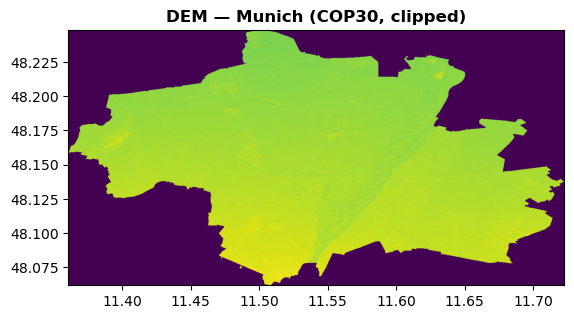

In [31]:
# DEM sanity check 
import yaml
from pathlib import Path
import rasterio
from rasterio.plot import show

# Load config and build path dynamically
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR = THESIS_PATH / "Data" / "00_raw_data" / "Munich"

# Point to the clipped DEM we just created
dem_path = RAW_DIR / "dem_COP30_munich_clipped.tif"

# Open and inspect
with rasterio.open(dem_path) as src:
    print("CRS:", src.crs)
    print("Resolution (x,y):", src.res)
    print("Bounds:", src.bounds)
    print("Width x Height (px):", src.width, "x", src.height)
    print("Dtype:", src.dtypes[0])
    print("NODATA:", src.nodata)

    arr = src.read(1, masked=True)
    print("Elevation (min/max):", float(arr.min()), float(arr.max()))

    # quick visual check
    _ = show(src, title="DEM — Munich (COP30, clipped)")


Now I'll define the grid cells (optional, will change)


In [32]:
# --- Build a 5×5 km grid over Munich (EPSG:25832) and save it ---

from pathlib import Path
import numpy as np
import geopandas as gpd
from shapely.geometry import box
import yaml

# Load config → build GPKG path inside 00_raw_data/Munich
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

# Load boundary and ensure metric CRS (ETRS89 / UTM 32N)
boundary = gpd.read_file(GPKG, layer="munich_boundary")
boundary_m = boundary.to_crs(25832)  # EPSG:25832

# Create 5 km fishnet over the bbox
cell = 5000  # meters
minx, miny, maxx, maxy = boundary_m.total_bounds
xs = np.arange(minx, maxx, cell)
ys = np.arange(miny, maxy, cell)
cells = [box(x, y, x + cell, y + cell) for x in xs for y in ys]
grid = gpd.GeoDataFrame(geometry=cells, crs=boundary_m.crs)

# Clip to city boundary
grid_city = gpd.overlay(grid, boundary_m, how="intersection", keep_geom_type=True)
grid_city["cell_id"] = np.arange(1, len(grid_city) + 1)

# Save (overwrite-safe if pyogrio available, else fall back to GeoPandas)
try:
    import pyogrio
    pyogrio.write_dataframe(grid_city, GPKG, layer="grid_5km", if_exists="replace")
    print("Saved (overwrite): grid_5km cells:", len(grid_city))
except Exception:
    # GeoPandas may fail if layer already exists; delete file once if needed
    try:
        grid_city.to_file(GPKG, layer="grid_5km", driver="GPKG")
        print("Saved: grid_5km cells:", len(grid_city))
    except Exception as e2:
        print("[error] Could not save layer 'grid_5km':", e2)


Saved: grid_5km cells: 24


In [33]:
# Helpers for clipping & length aggregation

import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
from shapely.ops import linemerge

def load_grid():
    g = gpd.read_file(GPKG, layer="grid_5km")
    return g[["cell_id", "geometry"]]

def to_utm(gdf):
    return gdf.to_crs(25832)  # consistent CRS for metric lengths

def intersect_and_length(lines_gdf_m, grid_m, keep_cols):
    """
    Intersect linework with the grid and compute length_m per cell.
    This version avoids duplicate 'cell_id' columns by doing a single overlay.
    """
    if lines_gdf_m is None or lines_gdf_m.empty:
        return gpd.GeoDataFrame(columns=["cell_id","length_m", *keep_cols, "geometry"],
                                geometry="geometry", crs=grid_m.crs)

    # Keep only requested tag cols (if they exist) and geometry
    keep_present = [c for c in (keep_cols or []) if c in lines_gdf_m.columns]
    lines_sel = lines_gdf_m[keep_present + ["geometry"]].copy()

    # Single overlay: lines ⨂ grid (grid contributes the unique 'cell_id')
    inter = gpd.overlay(lines_sel, grid_m[["cell_id","geometry"]], how="intersection")
    if inter.empty:
        return inter.assign(length_m=0)

    # Compute metric length in current (meter) CRS
    inter["length_m"] = inter.geometry.length

    # Return a tidy schema
    return inter[["cell_id", "length_m", *keep_present, "geometry"]]


def summarize_length_by(groups_df, by_cols):
    """Sum length within each cell grouped by tag(s)."""
    if groups_df.empty:
        return pd.DataFrame(columns=["cell_id", *by_cols, "length_m"])
    out = groups_df.groupby(["cell_id", *[c for c in by_cols if c in groups_df.columns]], dropna=False, as_index=False)["length_m"].sum()
    return out

def total_length_by_cell(lines_gdf_m, grid_m):
    inter = intersect_and_length(lines_gdf_m, grid_m, keep_cols=[])
    if inter.empty:
        return pd.DataFrame(columns=["cell_id","total_length_m"])
    return inter.groupby("cell_id", as_index=False)["length_m"].sum().rename(columns={"length_m":"total_length_m"})


In [34]:
# Aggregate Road Class, Main Road Separation, Road Surface, and (if present) Cycling Network per grid cell, for both years

# --- Aggregate Road Class, Main Road Separation, Road Surface, and Cycling Network per grid cell (2017 & 2023) ---

import yaml
from pathlib import Path
import pandas as pd
import geopandas as gpd

# ---- load config + build GPKG path (Data/00_raw_data/Munich) ----
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)
THESIS_PATH = Path(cfg["THESIS_PATH"])
GPKG = THESIS_PATH / "Data" / "00_raw_data" / "Munich" / "munich_bikeability_raw.gpkg"

# ---- small overwrite-safe writer (uses pyogrio if available) ----
def write_layer(gdf: gpd.GeoDataFrame, layer: str):
    if gdf is None or gdf.empty:
        print(f"[warn] not saving empty layer: {layer}")
        return
    try:
        import pyogrio
        pyogrio.write_dataframe(gdf, GPKG, layer=layer, if_exists="replace")
    except Exception:
        # first run usually fine; if layer exists and this fails, delete GPKG or install pyogrio
        gdf.to_file(GPKG, layer=layer, driver="GPKG")
    print(f"Saved {layer}")

# ---- helpers assumed to exist from earlier cells: load_grid(), to_utm(), intersect_and_length(), summarize_length_by(), total_length_by_cell() ----
grid_m = load_grid()   # should return the 25832 grid with 'cell_id'
years = ["2017", "2023"]

for year in years:
    print(f"\n=== Aggregations for {year} ===")

    # ---- Load layers & project to metric CRS ----
    roads = gpd.read_file(GPKG, layer=f"{year}_roads_all")
    roads_m = to_utm(roads)

    sep = gpd.read_file(GPKG, layer=f"{year}_main_road_separation")
    sep_m = to_utm(sep)

    surf = gpd.read_file(GPKG, layer=f"{year}_road_surface")
    surf_m = to_utm(surf)

    # Cycle routes member ways may be missing/empty → handle gracefully
    try:
        routes_m_tmp = gpd.read_file(GPKG, layer=f"{year}_cycle_routes_member_ways")
        routes_m = to_utm(routes_m_tmp)
    except Exception:
        routes_m = gpd.GeoDataFrame(columns=["geometry"], geometry="geometry", crs=roads_m.crs)

    # ---- 1) Road Class: length by 'highway' ----
    inter_rc = intersect_and_length(roads_m, grid_m, keep_cols=["highway"])
    rc_by = summarize_length_by(inter_rc, by_cols=["highway"])  # pandas DF: cell_id, highway, length_m

    # Total road length (any class)
    rc_total = total_length_by_cell(roads_m, grid_m)  # pandas DF: cell_id, total_length_m

    # ---- 2) Main Road Separation: total separated length & share ----
    inter_sep = intersect_and_length(sep_m, grid_m, keep_cols=[])
    sep_by_cell = (
        inter_sep.groupby("cell_id", as_index=False)["length_m"]
        .sum()
        .rename(columns={"length_m": "sep_length_m"})
    )

    rc_total_merged = rc_total.merge(sep_by_cell, on="cell_id", how="left").fillna({"sep_length_m": 0})
    # guard against divide-by-zero
    rc_total_merged["sep_share"] = (
        rc_total_merged["sep_length_m"] / rc_total_merged["total_length_m"]
    ).replace([pd.NA, float("inf")], 0).fillna(0)

    # ---- 3) Surface: length by 'surface' ----
    inter_surf = intersect_and_length(surf_m, grid_m, keep_cols=["surface"])
    surf_by = summarize_length_by(inter_surf, by_cols=["surface"])  # pandas DF: cell_id, surface, length_m

    # ---- 4) Cycling Network: length of route member ways (if present) ----
    if not routes_m.empty:
        inter_routes = intersect_and_length(routes_m, grid_m, keep_cols=[])
        routes_by_cell = (
            inter_routes.groupby("cell_id", as_index=False)["length_m"]
            .sum()
            .rename(columns={"length_m": "cycle_route_length_m"})
        )
    else:
        routes_by_cell = pd.DataFrame({"cell_id": grid_m["cell_id"], "cycle_route_length_m": 0})

    # ---- Convert to GeoDataFrames by merging grid geometry, then save ----

    # 4a) Road class by highway
    rc_by_g = grid_m[["cell_id", "geometry"]].merge(rc_by, on="cell_id", how="left").fillna({"length_m": 0})
    rc_by_g = gpd.GeoDataFrame(rc_by_g, geometry="geometry", crs=grid_m.crs)
    write_layer(rc_by_g, f"grid5k_{year}_roadclass_by_highway")

    # 4b) Surface by type
    surf_by_g = grid_m[["cell_id", "geometry"]].merge(surf_by, on="cell_id", how="left").fillna({"length_m": 0})
    surf_by_g = gpd.GeoDataFrame(surf_by_g, geometry="geometry", crs=grid_m.crs)
    write_layer(surf_by_g, f"grid5k_{year}_surface_by_type")

    # 4c) Totals + separation share
    rc_totals_g = (
        grid_m[["cell_id", "geometry"]]
        .merge(rc_total_merged, on="cell_id", how="left")
        .fillna({"total_length_m": 0, "sep_length_m": 0, "sep_share": 0})
    )
    rc_totals_g = gpd.GeoDataFrame(rc_totals_g, geometry="geometry", crs=grid_m.crs)
    write_layer(rc_totals_g, f"grid5k_{year}_road_totals_sepshare")

    # 4d) Cycle routes length
    routes_g = grid_m[["cell_id", "geometry"]].merge(routes_by_cell, on="cell_id", how="left").fillna({"cycle_route_length_m": 0})
    routes_g = gpd.GeoDataFrame(routes_g, geometry="geometry", crs=grid_m.crs)
    write_layer(routes_g, f"grid5k_{year}_cycle_routes_length")

print("\nAll grid aggregations saved to:", GPKG)


=== Aggregations for 2017 ===
Saved grid5k_2017_roadclass_by_highway
Saved grid5k_2017_surface_by_type
Saved grid5k_2017_road_totals_sepshare
Saved grid5k_2017_cycle_routes_length

=== Aggregations for 2023 ===
Saved grid5k_2023_roadclass_by_highway
Saved grid5k_2023_surface_by_type
Saved grid5k_2023_road_totals_sepshare
Saved grid5k_2023_cycle_routes_length

All grid aggregations saved to: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\munich_bikeability_raw.gpkg


In [39]:
# --- Compute slope per road segment from the DEM, then average per grid cell ---

import math, numpy as np, pandas as pd, rasterio, geopandas as gpd
from rasterio.sample import sample_gen  # keeps rasterio happy on some installs
from shapely.ops import linemerge
from shapely.geometry import LineString
from pyproj import Transformer
from pathlib import Path
import yaml

# ---- Load config + build standard paths ----
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR     = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
GPKG        = RAW_DIR / "munich_bikeability_raw.gpkg"

# DEM path (clipped) from the raw Munich folder
DEM_PATH = RAW_DIR / "dem_COP30_munich_clipped.tif"
if not DEM_PATH.exists():
    raise FileNotFoundError(f"DEM not found at: {DEM_PATH}. Run the DEM download/clip cell first.")

# Grid (EPSG:25832) from the earlier helper
grid_m = load_grid()

def densify_line(line_m: LineString, step_m=25.0) -> LineString:
    """Return a line with vertices every ~step_m (in meters)."""
    if line_m.is_empty or line_m.length <= step_m:
        return line_m
    n = max(2, int(math.ceil(line_m.length / step_m)) + 1)
    distances = np.linspace(0, line_m.length, n)
    pts = [line_m.interpolate(d) for d in distances]
    return LineString(pts)

def segment_avg_slope_percent(line_m: LineString, transformer_to_dem, dem_dataset, step_m=25.0) -> float:
    """Mean absolute grade (%) along a segment using sampled elevations."""
    if line_m.is_empty or line_m.length == 0:
        return 0.0

    # Densify in metric CRS
    line_d = densify_line(line_m, step_m=step_m)
    xs_m, ys_m = line_d.xy  # coords in EPSG:25832 (meters)

    # Transform to DEM CRS (e.g., EPSG:4326 for COP30)
    xs_dem, ys_dem = transformer_to_dem.transform(xs_m, ys_m)

    # Sample elevations
    coords = list(zip(xs_dem, ys_dem))
    vals = list(dem_dataset.sample(coords))
    zs = np.array([v[0] for v in vals], dtype="float32")

    # Handle NoData
    if dem_dataset.nodata is not None:
        zs = np.where(zs == dem_dataset.nodata, np.nan, zs)

    # Per-step slopes: Δz / step_m -> percent
    diffs = np.abs(np.diff(zs))
    with np.errstate(divide="ignore", invalid="ignore"):
        grades = 100.0 * diffs / step_m
    grades = grades[np.isfinite(grades)]
    if grades.size == 0:
        return 0.0
    return float(np.nanmean(grades))

def compute_segment_slopes(roads_layer_name: str, out_layer_segments: str, out_layer_gridmean: str, step_m=25.0):
    """Compute slope per road segment and length-weighted mean slope per 5km cell."""
    roads = gpd.read_file(GPKG, layer=roads_layer_name)
    roads_m = to_utm(roads)  # EPSG:25832

    if roads_m.empty:
        # Create empty outputs if no roads
        empty = roads_m.copy()
        empty["slope_pct"] = []
        empty.to_file(GPKG, layer=out_layer_segments, driver="GPKG")
        grid_m[["cell_id","geometry"]].assign(mean_slope_pct=np.nan).to_file(GPKG, layer=out_layer_gridmean, driver="GPKG")
        print(f"{roads_layer_name}: empty")
        return

    with rasterio.open(DEM_PATH) as dem:
        transformer_to_dem = Transformer.from_crs(roads_m.crs, dem.crs, always_xy=True)

        slopes = []
        for geom in roads_m.geometry:
            if geom is None or geom.is_empty:
                slopes.append(0.0)
                continue
            if geom.geom_type == "MultiLineString":
                merged = linemerge(geom)
                geom_use = merged if merged.geom_type == "LineString" else list(merged.geoms)[0]
            else:
                geom_use = geom
            slopes.append(segment_avg_slope_percent(geom_use, transformer_to_dem, dem, step_m=step_m))

    roads_m = roads_m.copy()
    roads_m["slope_pct"] = slopes
    roads_m.to_file(GPKG, layer=out_layer_segments, driver="GPKG")
    print("Saved segment slopes:", out_layer_segments)

    # Intersect with grid and compute length-weighted mean slope per cell
    inter = intersect_and_length(roads_m, grid_m, keep_cols=["slope_pct"])
    if inter.empty:
        grid_out = grid_m[["cell_id","geometry"]].assign(mean_slope_pct=np.nan)
    else:
        grp = inter.groupby("cell_id", as_index=False).apply(
            lambda df: pd.Series({
                "mean_slope_pct": (df["slope_pct"] * df["length_m"]).sum() / max(df["length_m"].sum(), 1e-9)
            })
        ).reset_index(drop=True)
        grid_out = grid_m[["cell_id","geometry"]].merge(grp, on="cell_id", how="left")

    grid_out = gpd.GeoDataFrame(grid_out, geometry="geometry", crs=grid_m.crs)
    grid_out.to_file(GPKG, layer=out_layer_gridmean, driver="GPKG")
    print("Saved grid mean slope:", out_layer_gridmean)

compute_segment_slopes("2023_roads_all", "2023_roads_all_with_slope", "grid5k_2023_mean_slope_pct", step_m=25.0)
compute_segment_slopes("2017_roads_all", "2017_roads_all_with_slope", "grid5k_2017_mean_slope_pct", step_m=25.0)


Saved segment slopes: 2023_roads_all_with_slope


C:\Users\Valeria\AppData\Local\Temp\ipykernel_21092\2642778638.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = inter.groupby("cell_id", as_index=False).apply(


Saved grid mean slope: grid5k_2023_mean_slope_pct
Saved segment slopes: 2017_roads_all_with_slope
Saved grid mean slope: grid5k_2017_mean_slope_pct


C:\Users\Valeria\AppData\Local\Temp\ipykernel_21092\2642778638.py:105: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = inter.groupby("cell_id", as_index=False).apply(


In [36]:
# To make sure the raw data from the Overpass downloads was successfully saved to the GeoPackage
# --- List layers in the GeoPackage (using config.yml path) ---
import yaml
from pathlib import Path
import fiona

# Load config and build GPKG path
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
GPKG = THESIS_PATH / "Data" / "00_raw_data" / "Munich" / "munich_bikeability_raw.gpkg"

with fiona.Env():
    layers = fiona.listlayers(str(GPKG))  # str() for safety with some Fiona versions
    print(f"Layers in GeoPackage ({GPKG}):")
    for name in layers:
        print("-", name)
    print(f"\nTotal layers: {len(layers)}")



Layers in GeoPackage (C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\munich_bikeability_raw.gpkg):
- munich_boundary
- 2017_roads_all
- 2017_main_road_separation
- 2017_road_surface
- 2017_cycle_routes_relations
- 2023_roads_all
- 2023_main_road_separation
- 2023_road_surface
- 2023_cycle_routes_relations
- grid_5km
- grid5k_2017_roadclass_by_highway
- grid5k_2017_surface_by_type
- grid5k_2017_road_totals_sepshare
- grid5k_2017_cycle_routes_length
- grid5k_2023_roadclass_by_highway
- grid5k_2023_surface_by_type
- grid5k_2023_road_totals_sepshare
- grid5k_2023_cycle_routes_length
- 2023_roads_all_with_slope
- grid5k_2023_mean_slope_pct

Total layers: 20


Here I give some visualizations of the data extracted

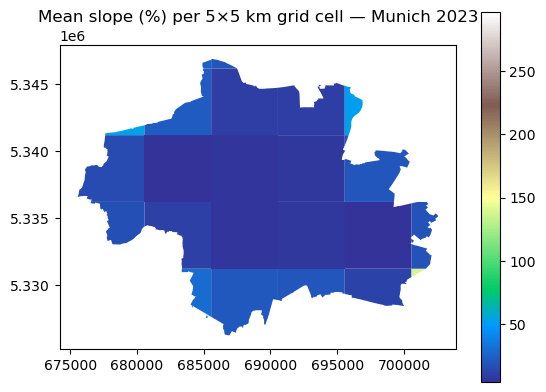

In [37]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file(GPKG, layer="grid5k_2023_mean_slope_pct")
gdf.plot(column="mean_slope_pct", cmap="terrain", legend=True)
plt.title("Mean slope (%) per 5×5 km grid cell — Munich 2023")
plt.show()


The next cell converts one spatial layer to a plain table so I can inspect or process it outside of GIS

In [40]:
#--- Export grid-level layers to CSV for both years and all factors ---

import yaml
from pathlib import Path
import geopandas as gpd
import fiona

# Load config and build paths
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

# Check which layers exist in the GPKG
layers_available = set(fiona.listlayers(str(GPKG)))

# For each year, export these grid layers (if present)
YEARS = ["2017", "2023"]
LAYER_PATTERNS = [
    "grid5k_{y}_road_totals_sepshare",  # totals + sep_share
    "grid5k_{y}_roadclass_by_highway",  # by highway class
    "grid5k_{y}_surface_by_type",       # by surface type
    "grid5k_{y}_cycle_routes_length",   # length of cycle-route member ways
    "grid5k_{y}_mean_slope_pct",        # topography (if computed)
]

exported = []

for y in YEARS:
    for patt in LAYER_PATTERNS:
        layer_name = patt.format(y=y)
        if layer_name not in layers_available:
            print(f"[skip] Layer not found in GPKG: {layer_name}")
            continue

        gdf = gpd.read_file(GPKG, layer=layer_name)

        # Drop geometry for CSV export
        df = gdf.drop(columns=[c for c in gdf.columns if c.lower() == "geometry"], errors="ignore")

        # Save CSV next to the GPKG (raw Munich folder)
        out_csv = RAW_DIR / f"{layer_name}.csv"
        df.to_csv(out_csv, index=False, encoding="utf-8")
        exported.append(out_csv)
        print(f"[ok] Exported: {out_csv}")

print("\nDone. Exported CSV files:")
for p in exported:
    print("-", p)


[ok] Exported: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\grid5k_2017_road_totals_sepshare.csv
[ok] Exported: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\grid5k_2017_roadclass_by_highway.csv
[ok] Exported: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\grid5k_2017_surface_by_type.csv
[ok] Exported: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\grid5k_2017_cycle_routes_length.csv
[ok] Exported: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\grid5k_2017_mean_slope_pct.csv
[ok] Exported: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\grid5k_2023_road_totals_sepshare.csv
[ok] Exported: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\grid5k_2023_roadclass_by_highway.csv
[ok] Exported: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\grid5k_2023_surface_by_type.csv
[ok] Exported: C:\Users\Valeria\OneDrive\

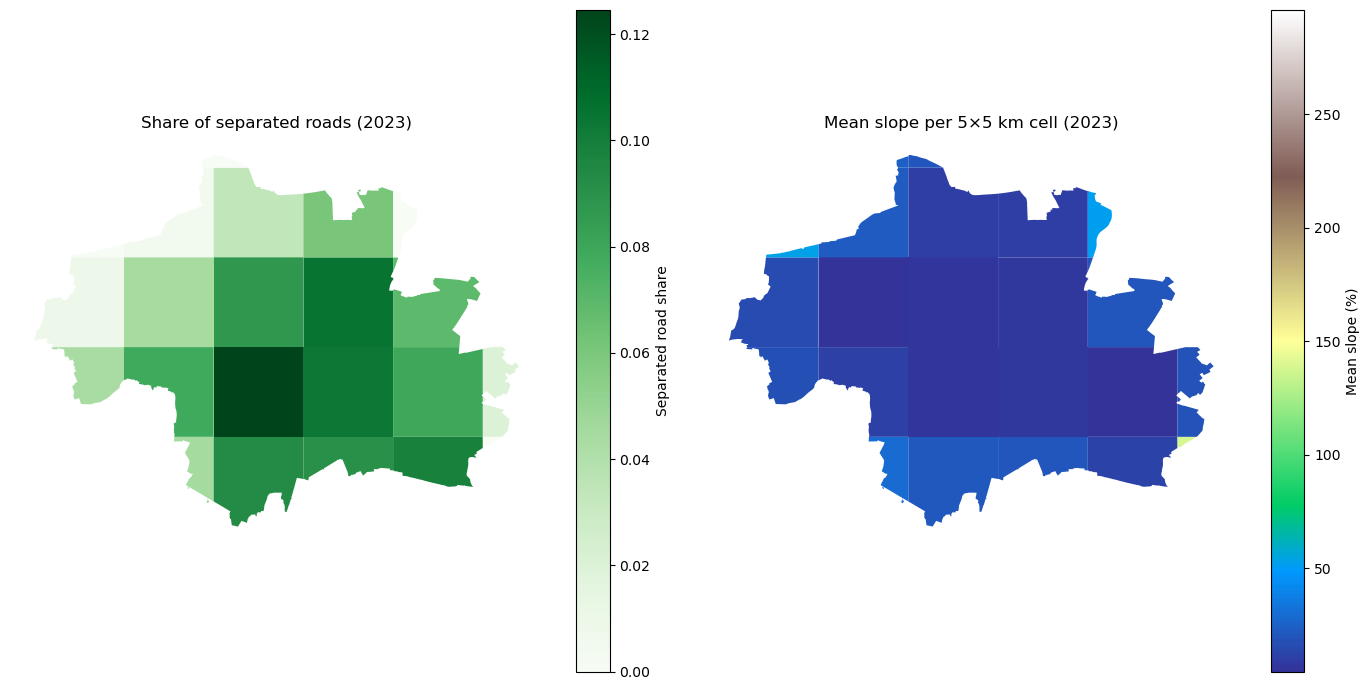

In [41]:
# --- Visualization example: separated roads vs. slope (2023) ---

import yaml
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

# Load config & build GeoPackage path
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

# Load both layers (2023)
roads_sep = gpd.read_file(GPKG, layer="grid5k_2023_road_totals_sepshare")
slope = gpd.read_file(GPKG, layer="grid5k_2023_mean_slope_pct")

# Merge slope info into the road-separation layer by cell_id
merged = roads_sep[["cell_id", "geometry", "sep_share"]].merge(
    slope[["cell_id", "mean_slope_pct"]],
    on="cell_id",
    how="left"
)

# --- 2-panel plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left map: share of separated roads
merged.plot(
    column="sep_share",
    cmap="Greens",
    legend=True,
    legend_kwds={"label": "Separated road share"},
    ax=axes[0],
    edgecolor="none"
)
axes[0].set_title("Share of separated roads (2023)")
axes[0].axis("off")

# Right map: mean slope (%)
merged.plot(
    column="mean_slope_pct",
    cmap="terrain",
    legend=True,
    legend_kwds={"label": "Mean slope (%)"},
    ax=axes[1],
    edgecolor="none"
)
axes[1].set_title("Mean slope per 5×5 km cell (2023)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


Grid CRS: EPSG:25832
Number of grid cells: 24
Grid bounds: [ 675559.30209927 5326194.44092317  702569.75894438 5346902.30616047]


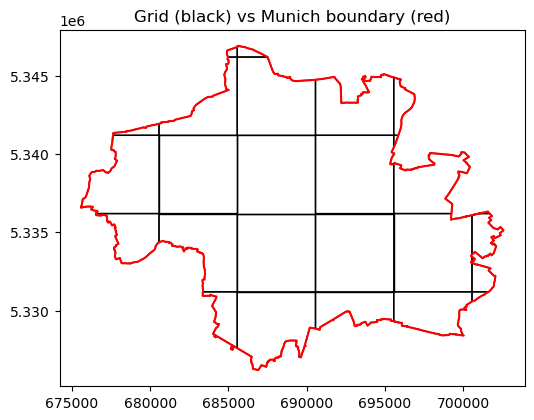

In [42]:
# --- Check the size and alignment of 5×5 km grid cells ---

import yaml
from pathlib import Path
import geopandas as gpd
import math
import matplotlib.pyplot as plt

# Load config and build GPKG path
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

# Load grid and Munich boundary layers
grid = gpd.read_file(GPKG, layer="grid_5km")
b = gpd.read_file(GPKG, layer="munich_boundary").to_crs(grid.crs)

# --- Print summary info ---
print("Grid CRS:", grid.crs)
print("Number of grid cells:", len(grid))
print("Grid bounds:", grid.total_bounds)  # (minx, miny, maxx, maxy) in meters if CRS is EPSG:25832

# --- Quick visual check ---
ax = grid.boundary.plot(figsize=(6, 6), linewidth=1, color="black")
b.boundary.plot(ax=ax, color="red", linewidth=1.5)
ax.set_title("Grid (black) vs Munich boundary (red)")
plt.show()



# Step 2: Map the bikeability factors
Purpose: To transform the raw OSM and DEM data I downloaded in Step 1 into quantitative, comparable factor scores for each road segment.
* Prepare data: Clean columns, assign IDs, align CRS, merge slope info
* Fetch and derived raw data (roads, surfaces, DEM, etc.).
* Build intermediate layers (road class, surface, slopes, separation, connectivity, etc.).
* Aggregate indicators for all selected factors on the 5×5 km grid:
    - score_V – Traffic-calmed share
    - score_R – Cycle facilities on main roads
    - score_O – Surface quality
    - score_T – Topography
    - score_K – Connectivity
* Scale each factor 0–10

In [43]:
# --- Locate the GeoPackage using config.yml (with a safe fallback search) ---

from pathlib import Path
import yaml
import fiona

# 1) Load Thesis base path from config.yml
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR     = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
GPKG        = RAW_DIR / "munich_bikeability_raw.gpkg"

print("Working dir:", Path.cwd())
print("Expecting GPKG at:", GPKG.resolve())
print("Exists?", GPKG.exists())

# 2) If not found, search upward and then the project tree for safety
if not GPKG.exists():
    # search from Thesis root downward
    matches = list(THESIS_PATH.rglob("munich_bikeability_raw.gpkg"))
    if matches:
        GPKG = matches[0]
        RAW_DIR = GPKG.parent
        print("Found at:", GPKG.resolve())
    else:
        # last resort: search from current working directory
        matches = list(Path.cwd().rglob("munich_bikeability_raw.gpkg"))
        if matches:
            GPKG = matches[0]
            RAW_DIR = GPKG.parent
            print("Found at (CWD search):", GPKG.resolve())
        else:
            raise FileNotFoundError(
                "Could not find munich_bikeability_raw.gpkg.\n"
                "Check config.yml (THESIS_PATH) or run Step 1 to create it."
            )

# 3) Sanity: list layers to confirm readable
print("\nLayers in GPKG:")
for name in fiona.listlayers(str(GPKG)):
    print(" -", name)


Working dir: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\src
Expecting GPKG at: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\munich_bikeability_raw.gpkg
Exists? True

Layers in GPKG:
 - munich_boundary
 - 2017_roads_all
 - 2017_main_road_separation
 - 2017_road_surface
 - 2017_cycle_routes_relations
 - 2023_roads_all
 - 2023_main_road_separation
 - 2023_road_surface
 - 2023_cycle_routes_relations
 - grid_5km
 - grid5k_2017_roadclass_by_highway
 - grid5k_2017_surface_by_type
 - grid5k_2017_road_totals_sepshare
 - grid5k_2017_cycle_routes_length
 - grid5k_2023_roadclass_by_highway
 - grid5k_2023_surface_by_type
 - grid5k_2023_road_totals_sepshare
 - grid5k_2023_cycle_routes_length
 - 2023_roads_all_with_slope
 - grid5k_2023_mean_slope_pct
 - 2017_roads_all_with_slope
 - grid5k_2017_mean_slope_pct


In [44]:
# --- Set GeoPackage and data directory using config.yml ---

import yaml
from pathlib import Path

# Load project path from config.yml
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

print("Using:", GPKG.resolve())


Using: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\munich_bikeability_raw.gpkg


The following cell:
* Reconnect the notebook to my main GeoPackage, and
* Provide a clean RAW_DIR path for any file exports (like CSVs, logs, or intermediate data).

In [53]:
# Imports and helpers
import math
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, Point, Polygon
from shapely.ops import unary_union


def _coalesce(*vals, default=None):  # Return the first non-empty / non-NaN value among several options
    for v in vals:
        if v is not None and not (isinstance(v, float) and np.isnan(v)):
            return v
    return default

def _to_int(val, default=None):    # Safely convert mixed or messy values (like '50 km/h', '30', or None) to an integer
    try:
        if val is None or (isinstance(val, float) and np.isnan(val)):
            return default
        return int(str(val).split()[0])
    except Exception:
        return default

def _parse_maxspeed(s):    # Parse OSM maxspeed tag to get a numeric speed in km/h
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return None
    txt = str(s).lower()
    if ";" in txt:
        txt = txt.split(";")[0]
    if "mph" in txt:
        try:
            mph = float(txt.replace("mph", "").strip())
            return round(mph * 1.60934)
        except Exception:
            return None
    try:
        return int("".join([c for c in txt if c.isdigit()]))
    except Exception:
        return None

def _norm_to_0_10(x, lo, hi, clamp=True, invert=False):      # Normalize a numeric value x into a 0–10 scale
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    if hi == lo:
        return 5.0
    t = (x - lo) / (hi - lo)
    t = float(np.clip(t, 0, 1)) if clamp else float(t)
    if invert:
        t = 1.0 - t
    return 10.0 * t
print("Cell 1: helpers loaded")

Cell 1: helpers loaded


The following cell:
* Takes a road segment and buffers it 
* Checks how much of that buffer overlaps with given polygon features (e.g., parks or water bodies).
* Returns the share of buffer area covered by those features — e.g., 0.25 → 25 % of the buffer around that road is “green area.”
  Useful later for the Aesthetics & Attractiveness or environmental factors (if we need it later)

_nearest_distance(line_geom, points_gdf, max_search_m=1000)
* Finds the distance (in meters) from a road segment to the nearest point feature (e.g., bike parking, intersections, etc.).
* Uses a spatial index for performance.
  Useful for Soft factors or proximity-based measures (e.g., nearest facility) (if we need it later)


In [ ]:
# Spatial helper utilities
def _clip_buffer_share(line_geom, polys_gdf, buffer_m=25.0):   # Calculate how much of the area within a buffer around a road overlaps with certain polygon features (e.g. green areas, parks, water)
    if line_geom is None or line_geom.is_empty:
        return 0.0
    buf = line_geom.buffer(buffer_m)
    if polys_gdf is None or polys_gdf.empty:
        return 0.0
    try:
        cand_idx = list(polys_gdf.sindex.intersection(buf.bounds))
        if not cand_idx:
            return 0.0
        inter = polys_gdf.iloc[cand_idx].intersection(buf)
    except Exception:
        inter = polys_gdf.intersection(buf)
    inter_area = inter.area.sum()
    return float(inter_area / buf.area) if buf.area > 0 else 0.0

def _nearest_distance(line_geom, points_gdf, max_search_m=1000):    # Find the distance (in meters) from a road segment to the nearest point feature
    if points_gdf is None or points_gdf.empty or line_geom is None:
        return np.nan
    try:
        cand_idx = list(points_gdf.sindex.intersection(line_geom.bounds))
        if not cand_idx:
            cand_idx = list(points_gdf.sindex.nearest(line_geom.bounds, num_results=50))
        if not cand_idx:
            return np.nan
        dists = points_gdf.iloc[cand_idx].distance(line_geom)
        return float(dists.min())
    except Exception:
        return float(points_gdf.distance(line_geom).min())
print("Cell 2: spatial utils loaded")

Cell 2: spatial utils loaded


The following cell:
- score_road_class(row)
    * Starts from a base score by highway type.
    * Adjusts for maxspeed (lower speed → higher score), lane count (more lanes → small penalty), and a small bonus for traffic controls.
    * Returns a 0–10 score.
- score_main_road_separation(row)
    * Detects facility type from cycleway, cycleway:left/right, bicycle, and segregated.
    * Scores: track = 10, lane = 7.5, shared = 5, none = 1, plus +1 if segregated.

In [45]:
# Individual factor scoring functions (part 1)
def score_road_class(row):
    hwy = str(_coalesce(row.get("highway"), "")).lower()
    base_map = {
        "motorway": 1, "trunk": 2, "primary": 3, "secondary": 5,
        "tertiary": 6, "unclassified": 6, "residential": 7,
        "living_street": 8, "service": 6, "cycleway": 9, "path": 7
    }
    base = base_map.get(hwy, 5)

    vmax = _parse_maxspeed(_coalesce(row.get("maxspeed"), row.get("maxspeed:lanes")))
    speed_score = _norm_to_0_10(vmax, 20, 70, invert=True) if vmax else 6

    lanes = _to_int(row.get("lanes"))
    lane_adj = {None: 0, 1: 0, 2: -0.5, 3: -1, 4: -1.5}.get(lanes, -2 if lanes and lanes >= 5 else 0)

    controls_bonus = 0.5 if str(row.get("traffic_sign", "")) or str(row.get("traffic_signals", "")) else 0
    score = np.clip(0.5 * base + 0.4 * speed_score + lane_adj + controls_bonus, 0, 10)
    return float(score)


def score_main_road_separation(row):
    c_main = str(row.get("cycleway", "")).lower()
    c_l = str(row.get("cycleway:left", "")).lower()
    c_r = str(row.get("cycleway:right", "")).lower()
    bicycle = str(row.get("bicycle", "")).lower()
    segregated = str(row.get("segregated", "")).lower()

    if any(t in ("track", "opposite_track") for t in [c_main, c_l, c_r]):
        facility = "track"
    elif any(t in ("lane", "opposite_lane", "both", "both:lane") for t in [c_main, c_l, c_r]):
        facility = "lane"
    elif bicycle in ("designated", "yes"):
        facility = "shared"
    else:
        facility = "none"

    seg_bonus = 1 if segregated in ("yes", "true", "1") else 0
    facil_score = {"track": 10, "lane": 7.5, "shared": 5, "none": 1}[facility]
    return float(np.clip(facil_score + seg_bonus, 0, 10))
print("Cell 3: scoring functions (part 1) loaded")

Cell 3: scoring functions (part 1) loaded


The following cell:

- score_cycling_network(row, deg_u, deg_v, sinuosity, cycle_network_flag)
    * Connectivity via mean node degree (deg_u, deg_v) → higher degree = better (0–10).
    * Directness via sinuosity (length / straight distance) → straighter = better (invert).
    * Coherence via a boolean flag if the segment is part of a signed cycle network.
    * Weighted mix: 45% connectivity, 35% straightness, 20% coherence.
- score_cycling_road_discomfort(row, obstacles_per_km, has_stops_per_km, parking_intrusion)
    * Penalizes obstacles and stops per km (inverted normalization), and parking intrusion (categorical). (Road Discomfort - could be used later)
- score_cycling_road_quality(row, width_m)
    * Uses OSM surface, smoothness, and width/est_width to score comfort/quality.
    * Weighted mix: 45% surface, 35% smoothness, 20% width.

In [47]:
# Scoring functions (part 2)
def score_cycling_network(row, deg_u=None, deg_v=None, sinuosity=None, cycle_network_flag=None): 
    mean_deg = np.mean([deg_u or 0, deg_v or 0])
    conn_score = _norm_to_0_10(mean_deg, 1, 4)
    straight_score = _norm_to_0_10(sinuosity, 1.0, 2.0, invert=True) if sinuosity else 5
    coh_score = 10 if cycle_network_flag else 5
    return float(np.clip(0.45*conn_score + 0.35*straight_score + 0.20*coh_score, 0, 10))


def score_cycling_road_discomfort(row, obstacles_per_km=None, has_stops_per_km=None, parking_intrusion=None):
    obs_score = _norm_to_0_10(obstacles_per_km or 0, 0, 8, invert=True)
    stops_score = _norm_to_0_10(has_stops_per_km or 0, 0, 10, invert=True)
    park_score = {0:10, 1:7, 2:4}.get(parking_intrusion or 1, 7)
    return float(np.clip(0.5*obs_score + 0.3*stops_score + 0.2*park_score, 0, 10))


def score_cycling_road_quality(row, width_m=None):
    surface = str(row.get("surface", "")).lower()
    smooth = str(row.get("smoothness", "")).lower()
    width = float(_coalesce(width_m, row.get("width"), row.get("est_width"), default=np.nan))

    surf_score = {
        "asphalt":10,"paved":9,"concrete":9,"paving_stones":7,"gravel":4,
        "ground":3,"dirt":2,"sand":1,"grass":1
    }.get(surface,6)
    smooth_score = {
        "excellent":10,"very_good":9,"good":8,"intermediate":6,
        "bad":4,"very_bad":3,"horrible":2,"impassable":0
    }.get(smooth,6)
    width_score = _norm_to_0_10(width, 1, 3) if not np.isnan(width) else 6
    return float(np.clip(0.45*surf_score + 0.35*smooth_score + 0.2*width_score, 0, 10))
print("Cell 4: scoring functions (part 2) loaded")

Cell 4: scoring functions (part 2) loaded


In [49]:
# Remaining factor scorers and geometry utilities 

def score_topography(slope_pct):
    # 0–9% mapped to 10–0; outside range clamped by _norm_to_0_10
    # > 9 %: practically too steep for regular commuting
    return float(_norm_to_0_10(slope_pct, 0, 9, invert=True)) if slope_pct is not None else 7

# Not used in my index, kept for completeness
def score_soft(d1=None, d2=None):
    def f(d): return _norm_to_0_10(d, 0, 600, invert=True) if d else np.nan
    m = np.nanmean([f(d1), f(d2)])
    return float(m if not np.isnan(m) else 6)

# Not used in my index, kept for completeness
def score_aesthetics(green_share=0, blue_share=0):
    g = _norm_to_0_10(green_share, 0, 0.6)
    b = _norm_to_0_10(blue_share, 0, 0.4)
    return float(np.clip(0.7*g + 0.3*b, 0, 10))

# Geometry helpers
from shapely.ops import linemerge
from shapely.geometry import LineString, Point

def compute_endpoint_degrees(edges_gdf, nodes_gdf=None, u_col="u", v_col="v"):
    # derive degrees from edge endpoints; works even without nodes_gdf
    if u_col in edges_gdf and v_col in edges_gdf:
        deg = pd.concat(
            [edges_gdf[[u_col]].rename(columns={u_col: "nid"}),
             edges_gdf[[v_col]].rename(columns={v_col: "nid"})],
            axis=0
        ).value_counts("nid").rename("deg")
        edges_gdf = edges_gdf.copy()
        edges_gdf["deg_u"] = edges_gdf[u_col].map(deg).fillna(0).astype(int)
        edges_gdf["deg_v"] = edges_gdf[v_col].map(deg).fillna(0).astype(int)
    else:
        edges_gdf = edges_gdf.copy()
        edges_gdf["deg_u"] = 3
        edges_gdf["deg_v"] = 3
    return edges_gdf

def compute_sinuosity(edges_gdf):
    """
    Compute length/straight_distance per edge.
    NOTE: Run on a metric CRS (e.g., EPSG:25832) so lengths are in meters.
    """
    out = edges_gdf.copy()
    vals = []
    for geom in out.geometry:
        if geom is None or geom.is_empty:
            vals.append(np.nan); continue
        if geom.geom_type != "LineString":
            try:
                merged = linemerge(geom)
                geom_use = merged if isinstance(merged, LineString) else list(merged.geoms)[0]
            except Exception:
                vals.append(np.nan); continue
        else:
            geom_use = geom
        try:
            straight = Point(geom_use.coords[0]).distance(Point(geom_use.coords[-1]))
            vals.append(geom_use.length / straight if straight > 0 else 1.0)
        except Exception:
            vals.append(np.nan)
    out["sinuosity"] = vals
    return out
print("Cell 5: scoring functions (part 2) loaded")

Cell 5: scoring functions (part 2) loaded


In [50]:
# --- Main builder function (aligned to the 5 factors; no I/O) ---

def build_bikeability_indicators(
    edges: gpd.GeoDataFrame,
    nodes: gpd.GeoDataFrame | None = None,
    cycle_network_flag_col: str | None = "in_cycle_route",  # set to None if I don't have this
):
    """
    Adds per-segment scores for the selected factors:
      - Road Class
      - Main Road Separation
      - Cycling Network (connectivity + directness + optional coherence flag)
      - Cycling Road Quality (surface/smoothness/width)
      - Topography (uses 'slope_pct' if present)
    Returns a copy of 'edges' with added score_* columns.
    """

    # 0) Work on a copy
    out = edges.copy()

    # 1) Ensure a metric CRS for lengths/sinuosity; use the to_utm() helper if available
    try:
        out_m = to_utm(out)  # assumes EPSG:25832
    except Exception:
        # Fallback: project if geographic, otherwise assume it's already metric
        if out.crs and out.crs.is_geographic:
            out_m = out.to_crs(25832)
        else:
            out_m = out

    # 2) Length in meters (for any later per-km metrics)
    if "length_m" not in out_m.columns:
        out_m["length_m"] = out_m.geometry.length

    # 3) Connectivity + directness inputs
    out_m = compute_endpoint_degrees(out_m, nodes)   # adds deg_u, deg_v
    out_m = compute_sinuosity(out_m)                 # adds sinuosity (expects metric CRS)

    # 4) Scores for my factors
    out_m["score_road_class"] = out_m.apply(score_road_class, axis=1)
    out_m["score_main_road_separation"] = out_m.apply(score_main_road_separation, axis=1)

    # Cycling Network: include coherence only if a flag column exists/was provided
    def _score_cyclenet_row(r):
        flag = bool(r.get(cycle_network_flag_col)) if cycle_network_flag_col else False
        return score_cycling_network(
            r,
            deg_u=r.get("deg_u"),
            deg_v=r.get("deg_v"),
            sinuosity=r.get("sinuosity"),
            cycle_network_flag=flag
        )
    out_m["score_cycling_network"] = out_m.apply(_score_cyclenet_row, axis=1)

    # Road Quality
    out_m["score_cycling_road_quality"] = out_m.apply(score_cycling_road_quality, axis=1)

    # Topography (use existing 'slope_pct' if present; otherwise neutral default 7)
    if "slope_pct" in out_m.columns:
        out_m["score_topography"] = out_m["slope_pct"].apply(score_topography)
    else:
        out_m["score_topography"] = score_topography(7)

    # 5) Return in the same CRS as input, carrying the new columns
    # If we reprojected, map scores back to the original CRS geometry
    if out_m.crs != out.crs and out.crs:
        # bring score columns back onto the original GeoDataFrame
        score_cols = [c for c in out_m.columns if c.startswith("score_") or c in ("length_m", "deg_u", "deg_v", "sinuosity", "slope_pct")]
        out = out.join(out_m[score_cols])
        return out
    else:
        return out_m

print("Cell 6: builder loaded")


Cell 6: builder loaded


Run the scorer on a small subset
The following cell:
* loads the 2017 roads-with-slope layer from the GPKG,
* samples a small subset,
* runs my build_bikeability_indicators on it.

In [54]:
# --- Load a small 2017 subset and run the scorer ---

import yaml
from pathlib import Path
import geopandas as gpd
import pandas as pd

# 1) Paths from config
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

# 2) Load the roads-with-slope layer from the GeoPackage
layer_name = "2017_roads_all_with_slope"
roads_2017 = gpd.read_file(GPKG, layer=layer_name)

print(f"Loaded {layer_name}: {len(roads_2017)} rows")
print("Columns:", list(roads_2017.columns)[:12], "...")

# 3) Take a small subset (choose ONE approach)

# Random sample of 500 segments:
subset = roads_2017.sample(n=min(500, len(roads_2017)), random_state=42)

# 4) Run the builder (assumes build_bikeability_indicators, to_utm, etc. are defined)
scored_subset = build_bikeability_indicators(subset, nodes=None, cycle_network_flag_col="in_cycle_route")

print("Scored columns added:",
      [c for c in scored_subset.columns if c.startswith("score_")][:10], "...")

# Peek
scored_subset.head()


Loaded 2017_roads_all_with_slope: 86127 rows
Columns: ['highway', 'maxspeed', 'oneway', 'lanes', 'name', 'bicycle', 'cycleway', 'segregated', 'junction', 'slope_pct', 'geometry'] ...
Scored columns added: ['score_road_class', 'score_main_road_separation', 'score_cycling_network', 'score_cycling_road_quality', 'score_topography'] ...


,highway,maxspeed,oneway,lanes,name,bicycle,cycleway,segregated,junction,slope_pct,geometry,length_m,deg_u,deg_v,sinuosity,score_road_class,score_main_road_separation,score_cycling_network,score_cycling_road_quality,score_topography
67769,footway,None,None,None,None,None,None,None,None,1.304281,"LINESTRING (690619.088 5329234.911, 690610.4 5...",24.480831,3,3,1.089147,4.9,1.0,7.187987,6.0,8.550799
28711,service,None,None,None,None,None,None,None,None,3.799968,"LINESTRING (690285.712 5337347.12, 690291.113 ...",20.921194,3,3,1.043458,5.4,1.0,7.347898,6.0,5.777814
28479,primary,50,yes,3,Ludwig-Ferdinand-Brücke,None,None,None,None,0.000000,"LINESTRING (686754.869 5336955.4, 686755.343 5...",9.053162,3,3,1.000000,2.1,1.0,7.500000,6.0,10.000000
55785,footway,None,None,None,None,None,None,None,None,0.000000,"LINESTRING (690811.661 5334944.364, 690822.383...",24.158823,3,3,5.607400,4.9,1.0,4.000000,6.0,10.000000
5012,living_street,None,None,None,Schwojerstraße,None,None,None,None,2.385672,"LINESTRING (677357.319 5338036.139, 677358.3 5...",169.812429,3,3,1.000810,6.4,1.0,7.497166,6.0,7.349253


In [56]:
csv_path = RAW_DIR / "2017_roads_all_with_slope.csv"
roads_2017_csv = pd.read_csv(csv_path)
print("CSV rows:", len(roads_2017_csv))


CSV rows: 86127


The following cell: 
* creates a copy of my road dataset (roads_2017) to avoid overwriting.
* ensures that all columns expected by the scorers (highway, surface, etc.) exist, filling missing ones with NaN.
* applies the scoring functions to compute factor scores.
* adds placeholders (NaN) for factors that need geometric or network data.

In [60]:
# --- Add safe defaults and run scorers on rows (attributes-only version) ---
import numpy as np
import pandas as pd

df = roads_2017.copy()  # or the subset variable

# Ensure expected columns exist (create empty if missing)
expected_cols = [
    "highway", "maxspeed", "lanes", "bicycle", "cycleway",
    "segregated", "smoothness", "surface", "slope_pct",
    "traffic_sign", "traffic_signals"
]
for col in expected_cols:
    if col not in df.columns:
        df[col] = np.nan

# If width / est_width are available, keep them; otherwise set to NaN
for wcol in ["width", "est_width"]:
    if wcol not in df.columns:
        df[wcol] = np.nan

# --- Apply scorers for the selected factors ---
df["score_road_class"] = df.apply(score_road_class, axis=1)
df["score_main_road_separation"] = df.apply(score_main_road_separation, axis=1)
df["score_cycling_road_quality"] = df.apply(score_cycling_road_quality, axis=1)
df["score_topography"] = df["slope_pct"].apply(score_topography)

# Cycling Network depends on geometry/connectivity (placeholder for now)
df["score_cycling_network"] = np.nan

# --- View a preview of the factor scores ---
print(df.filter(like="score_").head())


   score_road_class  score_main_road_separation  score_cycling_road_quality  \
0               1.9                         1.0                         6.0   
1               7.2                         1.0                         6.0   
2               7.2                         1.0                         6.0   
3               7.2                         1.0                         6.0   
4               4.6                         1.0                         6.0   

   score_topography  score_cycling_network  
0          7.105876                    NaN  
1          6.086019                    NaN  
2          8.495913                    NaN  
3          7.408832                    NaN  
4          0.000000                    NaN  


In [61]:
# --- Compute & SAVE per-segment factor scores (attributes-only CSV, optional GPKG) ---

import yaml
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

# Load config & paths
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)
THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR     = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
PROC_DIR    = THESIS_PATH / "Data" / "01_processed_data"
PROC_DIR.mkdir(parents=True, exist_ok=True)

GPKG        = RAW_DIR / "munich_bikeability_raw.gpkg"
YEAR        = "2017"     # change to "2023" as needed
LAYER_IN    = f"{YEAR}_roads_all_with_slope"   # source with geometry + slope_pct
CSV_OUT     = PROC_DIR / f"{YEAR}_roads_all_scores_attrs.csv"
LAYER_OUT   = f"{YEAR}_roads_all_with_scores"  # optional: write back with geometry

# Load source edges (keep geometry in memory; we’ll export attributes separately)
edges = gpd.read_file(GPKG, layer=LAYER_IN)

# Work on a copy (as plain DataFrame for attribute scoring)
df = edges.drop(columns="geometry").copy()

# Ensure expected columns exist (safe defaults)
expected_cols = [
    "highway","maxspeed","lanes","bicycle","cycleway","segregated",
    "smoothness","surface","slope_pct","traffic_sign","traffic_signals",
    "width","est_width"
]
for col in expected_cols:
    if col not in df.columns:
        df[col] = np.nan

# Ensure an ID to join on later (prefer osmid, else build one)
id_cols = [c for c in df.columns if c.lower() in ("osmid","id","edge_id")]
if id_cols:
    id_col = id_cols[0]
else:
    # create a stable-ish fallback ID from index (ok for within-session join)
    id_col = "edge_id"
    df[id_col] = np.arange(len(df))

# --- Apply scorers for my selected factors ---
df["score_road_class"]            = df.apply(score_road_class, axis=1)
df["score_main_road_separation"]  = df.apply(score_main_road_separation, axis=1)
df["score_cycling_road_quality"]  = df.apply(score_cycling_road_quality, axis=1)
df["score_topography"]            = df["slope_pct"].apply(score_topography)

# Placeholder for Cycling Network (to be computed later from connectivity)
df["score_cycling_network"] = np.nan

# Columns to export (attributes-only table to join later)
score_cols = [
    id_col,
    "score_road_class",
    "score_main_road_separation",
    "score_cycling_network",
    "score_cycling_road_quality",
    "score_topography",
]
df[score_cols].to_csv(CSV_OUT, index=False, encoding="utf-8")
print("Saved attributes CSV:", CSV_OUT)

# --- Optional: also write a GPKG layer with geometry + scores (handy for quick maps) ---
try:
    import pyogrio
    edges_with_scores = edges.merge(df[score_cols], on=id_col, how="left")
    pyogrio.write_dataframe(edges_with_scores, GPKG, layer=LAYER_OUT, if_exists="replace")
    print(f"Saved GPKG layer with geometry: {LAYER_OUT}")
except Exception as e:
    print("[note] Skipped GPKG write (pyogrio not available or other issue):", e)

# Quick preview
print(df[score_cols].head())


Saved attributes CSV: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\01_processed_data\2017_roads_all_scores_attrs.csv
[note] Skipped GPKG write (pyogrio not available or other issue): 'edge_id'
   edge_id  score_road_class  score_main_road_separation  \
0        0               1.9                         1.0   
1        1               7.2                         1.0   
2        2               7.2                         1.0   
3        3               7.2                         1.0   
4        4               4.6                         1.0   

   score_cycling_network  score_cycling_road_quality  score_topography  
0                    NaN                         6.0          7.105876  
1                    NaN                         6.0          6.086019  
2                    NaN                         6.0          8.495913  
3                    NaN                         6.0          7.408832  
4                    NaN                         6.0          0.000000  


In [64]:
# Do all layers have geometries, CRS, and expected feature counts?
import yaml
from pathlib import Path
import fiona

# Load config.yml
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# Build path to GeoPackage
THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

# Inspect layers
info = {}
for lyr in fiona.listlayers(str(GPKG)):
    try:
        with fiona.open(str(GPKG), layer=lyr) as src:
            gtype = src.schema.get("geometry")       # 'LineString', 'Polygon', etc.
            count = len(src)                         # feature count
            crs = src.crs_wkt or src.crs             # coordinate system
        info[lyr] = {"geom": gtype, "count": count, "crs": bool(crs)}
    except Exception as e:
        info[lyr] = {"geom": f"Error: {type(e).__name__}", "count": None, "crs": False}

# Print summary
print(f"Layers in: {GPKG}\n")
for lyr, meta in info.items():
    print(f"- {lyr}: {meta['geom']}  (features={meta['count']}, crs={'yes' if meta['crs'] else 'no'})")


Layers in: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\Data\00_raw_data\Munich\munich_bikeability_raw.gpkg

- munich_boundary: Polygon  (features=1, crs=yes)
- 2017_roads_all: LineString  (features=86127, crs=yes)
- 2017_main_road_separation: LineString  (features=1385, crs=yes)
- 2017_road_surface: LineString  (features=25438, crs=yes)
- 2017_cycle_routes_relations: Unknown  (features=88, crs=yes)
- 2023_roads_all: LineString  (features=110387, crs=yes)
- 2023_main_road_separation: LineString  (features=4106, crs=yes)
- 2023_road_surface: LineString  (features=76385, crs=yes)
- 2023_cycle_routes_relations: Unknown  (features=102, crs=yes)
- grid_5km: MultiPolygon  (features=24, crs=yes)
- grid5k_2017_roadclass_by_highway: MultiPolygon  (features=310, crs=yes)
- grid5k_2017_surface_by_type: MultiPolygon  (features=335, crs=yes)
- grid5k_2017_road_totals_sepshare: MultiPolygon  (features=24, crs=yes)
- grid5k_2017_cycle_routes_length: MultiPolygon  (features=24, crs=yes)
- grid5k_2023

In [65]:
# confirms the correct layer is readable and contains the expected columns before I start applying the scoring and aggregation steps
# Load a specific edges layer from the GeoPackage (config-based) 

import yaml
from pathlib import Path
import geopandas as gpd

# Load Thesis path from config.yml
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# Build GeoPackage path
THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

# Choose layer to inspect
edges_layer = "2017_roads_all_with_slope"   # change to "2023_..." when needed

# Read layer
edges = gpd.read_file(GPKG, layer=edges_layer)

# Print diagnostics
print(f"Loaded layer: {edges_layer}")
print("Number of edges:", len(edges))
print("CRS:", edges.crs)
print("Columns (first 25):", list(edges.columns)[:25])


Loaded layer: 2017_roads_all_with_slope
Number of edges: 86127
CRS: EPSG:25832
Columns (first 25): ['highway', 'maxspeed', 'oneway', 'lanes', 'name', 'bicycle', 'cycleway', 'segregated', 'junction', 'slope_pct', 'geometry']


Here we will compute:
* R (Main road separation): share of primary/secondary road length that has a cycle facility; scored 0–10 via the bins in Table 2.
* K (Connectivity): count of cycle-network intersections per grid (scaled to the 5×5 km area), then score using Winters-style thresholds after applying the area scaling factor.
* T (Topography): use my grid5k_{year}_mean_slope_pct layer; map mean slope to 0–10.
* O (Road quality): length-weighted surface quality score per grid from OSM surface tags; use Table 5 mapping (asphalt→10, concrete→10/9, … cobblestone/sand→0).
* V (Traffic-calmed / “road class” proxy): share of calm & bike-friendly network: include local/tertiary/unclassified/living_street/plus all cycle tracks/lanes (with separate cycle tracks counted double, as suggested); bin to 0–10.

Below is a s cell that: 
* loads paths from the config.yml,
* defines scoring bins exactly like the tables,
* builds V, R, O from the line layers,
* builds T from the DEM-derived grid layer,
* builds K by counting intersections of bike-eligible edges within each grid and scales thresholds to 25 km² cells,
* saves outputs (GPKG layers + CSVs) for both 2017 and 2023.

In [66]:
# --- Build grid-level factor indicators V, R, K, T, O (0–10), save to GPKG + CSV ---
import yaml
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
from shapely.ops import unary_union
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------
# Paths (from config.yml)
# ------------------------
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR     = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
PROC_DIR    = THESIS_PATH / "Data" / "01_processed_data"
PROC_DIR.mkdir(parents=True, exist_ok=True)

GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"
YEARS = ["2017", "2023"]

# ------------------------
# Helpers
# ------------------------
def to_utm(gdf, epsg=25832):
    if gdf.crs is None:
        # The layers are in WGS84; set if missing
        gdf = gdf.set_crs(4326)
    return gdf.to_crs(epsg)

def length_by_cell(lines_m, grid_m, keep_mask=None):
    """Return DataFrame[cell_id, length_m] of line length by grid cell."""
    if keep_mask is not None:
        lines_m = lines_m.loc[keep_mask].copy()
    if lines_m.empty:
        return pd.DataFrame({"cell_id": grid_m["cell_id"], "length_m": 0})
    inter = gpd.overlay(lines_m, grid_m[["cell_id","geometry"]], how="intersection", keep_geom_type=True)
    inter["seg_len"] = inter.geometry.length
    return inter.groupby("cell_id", as_index=False)["seg_len"].sum().rename(columns={"seg_len":"length_m"})

def classify_surface_score(surface: str) -> float:
    s = (surface or "").lower()
    # Table 5 inspired mapping
    if any(k in s for k in ["asphalt"]): return 10
    if any(k in s for k in ["concrete"]): return 9
    if any(k in s for k in ["paving_stones","sett","paver"]): return 6
    if any(k in s for k in ["earth","ground","wood","crushed","fine_gravel","gravel","grass"]): return 4
    if any(k in s for k in ["cobble","cobblestone","sand"]): return 0
    if "paved" in s: return 9
    if "unpaved" in s: return 3
    return 6  # neutral default

def score_from_bins(value, edges):
    """
    Map a value to 0–10 by bin edges list like:
    [(0,2),(2,4),(4,6),(6,8),(8,10)] → returns 0..10 stepwise.
    Expects 'edges' as sorted thresholds for the category boundaries.
    """
    # returns category index [0..5] then map to {0,2,4,6,8,10}
    labels = [0,2,4,6,8,10]
    for i, thr in enumerate(edges):
        if value < thr:
            return labels[i]
    return labels[-1]

def area_km2(poly_gdf):
    return float(poly_gdf.to_crs(3857).geometry.area.sum() / 1e6)

# ------------------------
# Load shared layers
# ------------------------
grid = gpd.read_file(GPKG, layer="grid_5km")
grid_m = to_utm(grid)  # EPSG:25832
grid_area_km2 = area_km2(grid_m) / len(grid_m)  # each cell ~25 km²

# Winters table is for 400m cells (0.16 km²). Scale thresholds by area ratio (Eq. 1).
winters_cell_km2 = 0.16
scaling = grid_area_km2 / winters_cell_km2  # Eq (1): G / G_s
# Table 3 thresholds (# of crossings): [1,50,150,298,497,746,994,1243,1492,2723]
K_THRESHOLDS_BASE = [1,50,150,298,497,746,994,1243,1492,2723]
K_THRESHOLDS_SCALED = [t * scaling for t in K_THRESHOLDS_BASE]

for year in YEARS:
    print(f"\n=== Building indicators for {year} ===")

    # ---- Load required layers
    roads = gpd.read_file(GPKG, layer=f"{year}_roads_all")
    surf  = gpd.read_file(GPKG, layer=f"{year}_road_surface")
    sep   = gpd.read_file(GPKG, layer=f"{year}_main_road_separation")
    slope_g = gpd.read_file(GPKG, layer=f"grid5k_{year}_mean_slope_pct")  # mean_slope_pct by cell

    # Project to metric CRS
    roads_m = to_utm(roads)
    surf_m  = to_utm(surf)
    sep_m   = to_utm(sep)

    # ------------- V: traffic-calmed / bike-friendly share (Table 1) -------------
    # "Calm" classes (proxy for lower speed/volume) + all cycle facilities
    calm_classes = {"tertiary","unclassified","residential","living_street","service","cycleway","path","track"}
    hwy = roads_m["highway"].astype(str).str.lower().fillna("")
    cycle_tags = roads_m["cycleway"].astype(str).str.lower().fillna("")

    is_calm = hwy.isin(calm_classes)
    # “Track” (separate) gets double weight; lanes and designated/shared count as 1×
    is_track = cycle_tags.str.contains("track|opposite_track")
    is_lane  = cycle_tags.str.contains("lane|opposite_lane|both")
    is_shared= roads_m["bicycle"].astype(str).str.lower().isin(["yes","designated"])

    base_len = length_by_cell(roads_m, grid_m)
    calm_len = length_by_cell(roads_m, grid_m, keep_mask=is_calm)

    # Add cycle facilities on *any* road
    fac_lane_len  = length_by_cell(roads_m, grid_m, keep_mask=is_lane)
    fac_shared_len= length_by_cell(roads_m, grid_m, keep_mask=is_shared)
    fac_track_len = length_by_cell(roads_m, grid_m, keep_mask=is_track)  # will be doubled

    # Combine into V numerator
    v_df = base_len.merge(calm_len, on="cell_id", how="left", suffixes=("_tot","_calm")).fillna(0)
    v_df = v_df.merge(fac_lane_len,  on="cell_id", how="left").rename(columns={"length_m":"len_lane"}).fillna(0)
    v_df = v_df.merge(fac_shared_len,on="cell_id", how="left").rename(columns={"length_m":"len_shared"}).fillna(0)
    v_df = v_df.merge(fac_track_len, on="cell_id", how="left").rename(columns={"length_m":"len_track"}).fillna(0)

    v_df["V_share"] = (v_df["length_m_calm"] + v_df["len_lane"] + v_df["len_shared"] + 2.0*v_df["len_track"]) / v_df["length_m_tot"]
    v_df["V_share"] = v_df["V_share"].replace([np.inf, -np.inf], np.nan).fillna(0) * 100.0

    # Table 1 bins for % calm: [26,58,75,87,100] → scores 0,2,4,6,8,10
    V_BINS = [26,58,75,87,100]
    v_df["score_V"] = v_df["V_share"].apply(lambda x: score_from_bins(x, V_BINS))

    # ------------- R: cycle paths on main roads (Table 2) -------------
    is_main = hwy.isin({"primary","secondary","primary_link","secondary_link"})
    main_len = length_by_cell(roads_m, grid_m, keep_mask=is_main)
    main_with_fac = is_main & (is_track | is_lane)
    main_fac_len = length_by_cell(roads_m, grid_m, keep_mask=main_with_fac)

    r_df = main_len.merge(main_fac_len, on="cell_id", how="left", suffixes=("_main","_fac")).fillna(0)
    r_df["R_share"] = (r_df["length_m_fac"] / r_df["length_m_main"]).replace([np.inf, -np.inf], np.nan).fillna(0) * 100.0

    # Table 2 bins for % coverage: [21,47,67,86,100]
    R_BINS = [21,47,67,86,100]
    r_df["score_R"] = r_df["R_share"].apply(lambda x: score_from_bins(x, R_BINS))

    # ------------- O: surface quality (Table 5) -------------
    # classify each line, then length-weighted mean per cell
    surf_m = surf_m.copy()
    surf_m["surf_score"] = surf_m["surface"].apply(classify_surface_score)
    inter = gpd.overlay(surf_m[["surface","surf_score","geometry"]], grid_m[["cell_id","geometry"]], how="intersection")
    inter["seg_len"] = inter.geometry.length
    o_grp = inter.groupby("cell_id", as_index=False).apply(
        lambda df: pd.Series({"O_len_m": df["seg_len"].sum(),
                              "score_O": (df["surf_score"]*df["seg_len"]).sum()/max(df["seg_len"].sum(),1e-9)})
    ).reset_index(drop=True)

    # ------------- T: topography (Table 4) -------------
    # mean_slope_pct is already per-cell; map to 0–10 (lower slope → higher score)
    t_df = slope_g[["cell_id","mean_slope_pct"]].copy()
    def score_T(s):
        if pd.isna(s): return np.nan
        # Table 4 (invert): <=0%→10, <0.5%→8, <2%→6, <5%→4, <10%→2, >=10%→0
        # (Winters table lists also >20%; we’ll clamp >=10 to 0 for simplicity)
        if s <= 0:   return 10
        if s < 0.5:  return 8
        if s < 2:    return 6
        if s < 5:    return 4
        if s < 10:   return 2
        return 0
    t_df["score_T"] = t_df["mean_slope_pct"].apply(score_T)

    # ------------- K: connectivity (Table 3 + Eq 1 scaling) -------------
    # Build a light-weight intersection count from edges: endpoints inside each cell, degree >= 3
    # Prepare bike-eligible edges (exclude motorway/trunk)
    exclude = {"motorway","motorway_link","trunk","trunk_link"}
    roads_bike = roads_m[~roads_m["highway"].astype(str).str.lower().isin(exclude)].copy()
    # Extract endpoints
    def endpoints(line: LineString):
        try:
            coords = list(line.coords)
            return coords[0], coords[-1]
        except Exception:
            return None, None
    pts = []
    for geom in roads_bike.geometry:
        if geom is None or geom.is_empty: continue
        if geom.geom_type == "LineString":
            a,b = endpoints(geom); 
            if a and b: pts.extend([a,b])
        elif geom.geom_type == "MultiLineString":
            for g in geom.geoms:
                a,b = endpoints(g); 
                if a and b: pts.extend([a,b])
    if pts:
        nodes = gpd.GeoDataFrame(geometry=gpd.points_from_xy([p[0] for p in pts], [p[1] for p in pts]), crs=roads_bike.crs)
        # round to ~2 m to collapse duplicates
        nodes["qx"] = (nodes.geometry.x/2).round().astype(int)
        nodes["qy"] = (nodes.geometry.y/2).round().astype(int)
        deg = nodes.groupby(["qx","qy"]).size().rename("deg").reset_index()
        deg_g = gpd.GeoDataFrame(deg, geometry=gpd.points_from_xy(deg["qx"]*2, deg["qy"]*2), crs=nodes.crs)
        # degree>=3 as intersection proxy
        deg_g["is_intersection"] = deg_g["deg"] >= 3
        # count per grid cell
        interK = gpd.sjoin(deg_g[deg_g["is_intersection"]], grid_m[["cell_id","geometry"]], how="left", predicate="within")
        k_counts = interK.groupby("cell_id").size().rename("K_count").reset_index()
    else:
        k_counts = pd.DataFrame({"cell_id": grid_m["cell_id"], "K_count": 0})

    k_df = grid_m[["cell_id"]].merge(k_counts, on="cell_id", how="left").fillna({"K_count":0})
    # Score with Winters thresholds scaled to 25 km²
    def score_K(n):
        return score_from_bins(float(n), K_THRESHOLDS_SCALED)
    k_df["score_K"] = k_df["K_count"].apply(score_K)

    # ------------------------
    # Combine & Save
    # ------------------------
    out = grid_m[["cell_id","geometry"]].merge(v_df[["cell_id","V_share","score_V"]], on="cell_id", how="left") \
        .merge(r_df[["cell_id","R_share","score_R"]], on="cell_id", how="left") \
        .merge(o_grp[["cell_id","score_O"]], on="cell_id", how="left") \
        .merge(t_df[["cell_id","mean_slope_pct","score_T"]], on="cell_id", how="left") \
        .merge(k_df[["cell_id","K_count","score_K"]], on="cell_id", how="left")

    out = gpd.GeoDataFrame(out, geometry="geometry", crs=grid_m.crs)

    layer_name = f"grid5k_{year}_factor_scores_VRKT0"
    out.to_file(GPKG, layer=layer_name, driver="GPKG")
    csv_path = RAW_DIR / f"{layer_name}.csv"
    out.drop(columns="geometry").to_csv(csv_path, index=False, encoding="utf-8")

    print(f"[ok] Saved {layer_name} to GPKG and CSV")
    print("    Columns:", [c for c in out.columns if c.startswith("score_") or c.endswith("_share") or c in ("K_count","mean_slope_pct")])



=== Building indicators for 2017 ===


C:\Users\Valeria\AppData\Local\Temp\ipykernel_21092\590993256.py:154: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  o_grp = inter.groupby("cell_id", as_index=False).apply(


[ok] Saved grid5k_2017_factor_scores_VRKT0 to GPKG and CSV
    Columns: ['V_share', 'score_V', 'R_share', 'score_R', 'score_O', 'mean_slope_pct', 'score_T', 'K_count', 'score_K']

=== Building indicators for 2023 ===


C:\Users\Valeria\AppData\Local\Temp\ipykernel_21092\590993256.py:154: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  o_grp = inter.groupby("cell_id", as_index=False).apply(


[ok] Saved grid5k_2023_factor_scores_VRKT0 to GPKG and CSV
    Columns: ['V_share', 'score_V', 'R_share', 'score_R', 'score_O', 'mean_slope_pct', 'score_T', 'K_count', 'score_K']


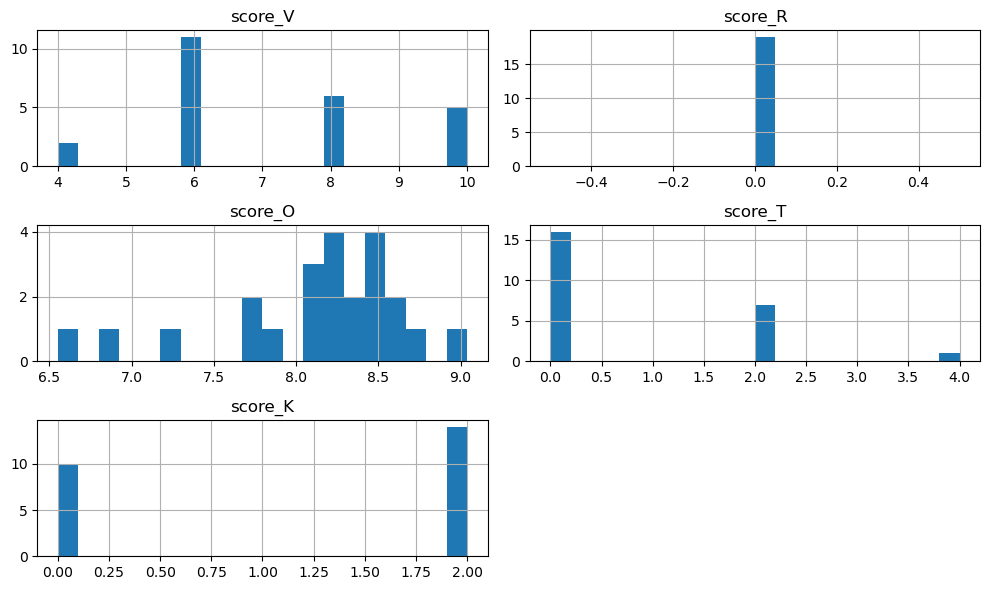

In [67]:
# Histograms to see distribution of scores (should span 0–10, no NaNs explosion):
import matplotlib.pyplot as plt, geopandas as gpd
yr = "2023"
layer = f"grid5k_{yr}_factor_scores_VRKT0"
g = gpd.read_file(GPKG, layer=layer)

g[["score_V","score_R","score_O","score_T","score_K"]].hist(bins=20, figsize=(10,6))
plt.tight_layout(); plt.show()


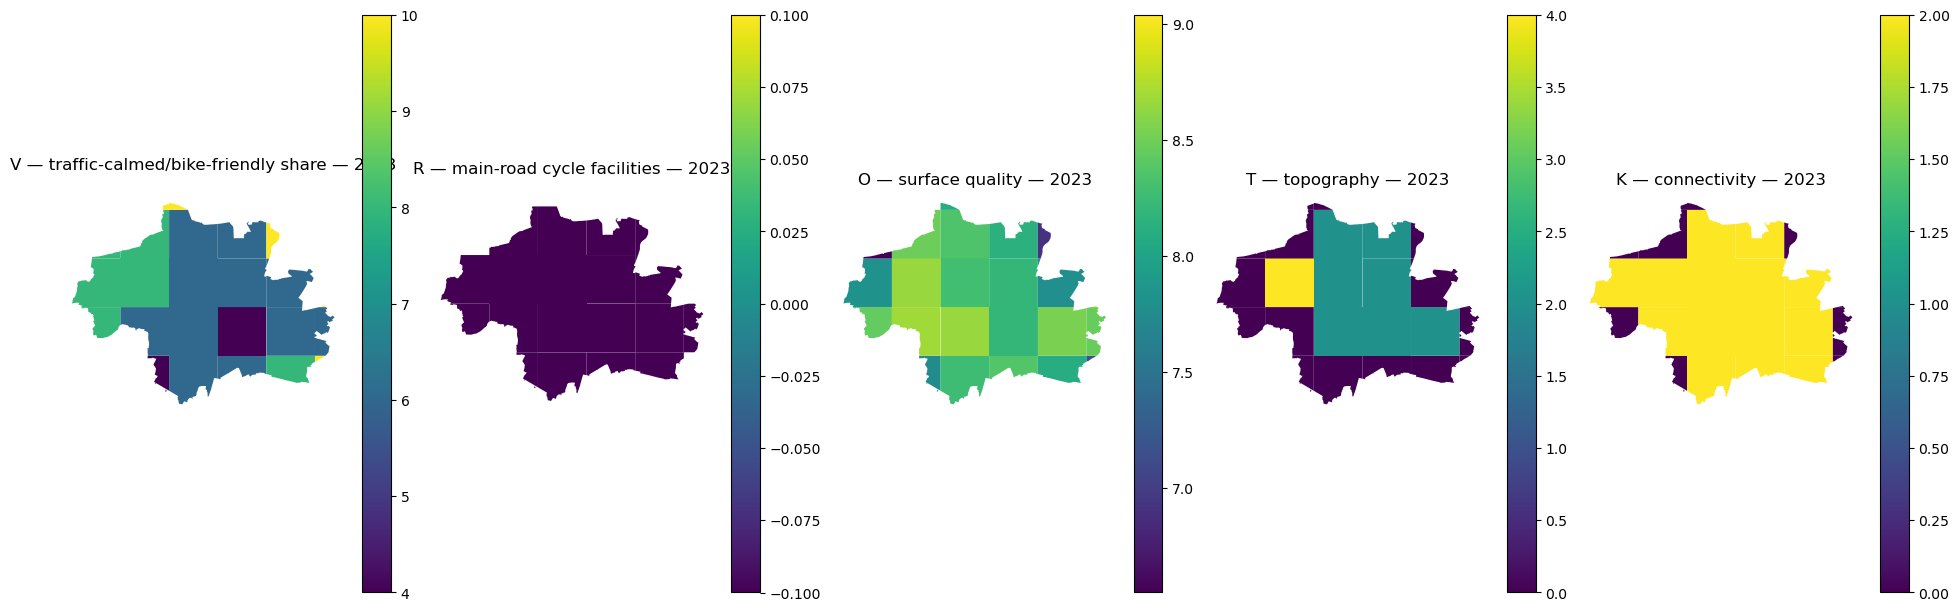

Saved: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\plots\factor_maps_2017.png
Saved: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\plots\factor_maps_2023.png


In [71]:
# Factor maps for all indicators (V, R, O, T, K) 

import yaml
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

# Load paths
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)
THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR  = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
PLOTS   = THESIS_PATH / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

FACTORS = [
    ("score_V", "V — traffic-calmed/bike-friendly share"),
    ("score_R", "R — main-road cycle facilities"),
    ("score_O", "O — surface quality"),
    ("score_T", "T — topography"),
    ("score_K", "K — connectivity"),
]

def plot_factor_maps(year: str, save_png: bool = False):
    layer = f"grid5k_{year}_factor_scores_VRKT0"
    g = gpd.read_file(GPKG, layer=layer)

    # Make a 1×5 panel
    n = len(FACTORS)
    fig, axes = plt.subplots(1, n, figsize=(3.8*n, 6), constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, (col, title) in zip(axes, FACTORS):
        if col not in g.columns:
            ax.set_title(f"{title}\n(missing)")
            ax.axis("off")
            continue
        g.plot(column=col, legend=True, ax=ax, edgecolor="none")  # default colormap
        ax.set_title(f"{title} — {year}")
        ax.axis("off")

    if save_png:
        out_path = PLOTS / f"factor_maps_{year}.png"
        plt.savefig(out_path, dpi=200)
        print("Saved:", out_path)
        plt.close(fig)
    else:
        plt.show()

# interactively view one year 
plot_factor_maps("2023", save_png=False)

# batch save both years to /plots 
for yr in ["2017", "2023"]:
    plot_factor_maps(yr, save_png=True)


# Step 3: Weighting + Index Computation
The weights:
* Road Class - 0.171
* Main Road Separation - 0.237
* Cycling Network - 0.158
* Road Surface - 0.237
* Topography - 0.197
The formula:
    BI = w1·V + w2·R + w3·K + w4·O + w5·T

The following cell
* Uses the normalized weights:
    BI = 0.171·V + 0.237·R + 0.158·K + 0.237·O + 0.197·T
* Handles missing factor values by redistributing the remaining weights on that row.
* Writes:
    - grid5k_2017_BI, grid5k_2023_BI (to the GeoPackage)
    - CSVs to Data/01_processed_data/

In [72]:
# --- Compute Bikeability Index (BI) for 2017 & 2023 using the weights ---

import yaml
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd

# 1) Paths from config.yml
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR     = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
PROC_DIR    = THESIS_PATH / "Data" / "01_processed_data"
PROC_DIR.mkdir(parents=True, exist_ok=True)

GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"
YEARS = ["2017", "2023"]

# 2) Normalized weights (sum = 1.0)
WEIGHTS = {
    "score_V": 0.171,  # Road Class (traffic-calmed/bike-friendly share)
    "score_R": 0.237,  # Main Road Separation
    "score_K": 0.158,  # Cycling Network (connectivity)
    "score_O": 0.237,  # Road Surface quality
    "score_T": 0.197,  # Topography (slope; lower is better)
}

FACTOR_COLS = list(WEIGHTS.keys())

def compute_bi(df: pd.DataFrame, weights: dict, out_col="score_BI") -> pd.DataFrame:
    """Compute 0–10 BI as a weighted average of factor scores, re-normalizing weights per-row if some factors are NaN."""
    arr = df[FACTOR_COLS].copy()

    # mask of available (non-na) factors per row
    valid = ~arr.isna()
    # row-wise sum of available weights
    w = pd.Series(weights)
    w_available = valid.mul(w, axis=1).sum(axis=1)

    # weighted sum over available factors
    weighted_sum = arr.mul(w, axis=1).sum(axis=1)

    # avoid divide-by-zero; if no factors present for a row, set NaN
    bi = np.where(w_available > 0, weighted_sum / w_available, np.nan)

    # clamp to [0, 10] just in case
    df[out_col] = np.clip(bi, 0, 10)
    return df

# 3) Process both years
for year in YEARS:
    layer_in  = f"grid5k_{year}_factor_scores_VRKT0"
    layer_out = f"grid5k_{year}_BI"
    csv_out   = PROC_DIR / f"{layer_out}.csv"

    # Read factor layer
    g = gpd.read_file(GPKG, layer=layer_in)

    # Compute BI
    g = compute_bi(g, WEIGHTS, out_col="score_BI")

    # Save CSV (attributes only)
    g.drop(columns="geometry").to_csv(csv_out, index=False, encoding="utf-8")

    # Save GPKG layer (overwrite-safe if pyogrio available)
    try:
        import pyogrio
        pyogrio.write_dataframe(g, GPKG, layer=layer_out, if_exists="replace")
    except Exception:
        # fallback with GeoPandas (may fail if layer exists — delete manually if needed)
        g.to_file(GPKG, layer=layer_out, driver="GPKG")

    print(f"[ok] {year}: wrote '{layer_out}' to GPKG and '{csv_out.name}' to 01_processed_data")

# Quick peek at 2023 BI distribution
g2023 = gpd.read_file(GPKG, layer="grid5k_2023_BI")
print("\n2023 BI preview:")
print(g2023[["cell_id", "score_V", "score_R", "score_K", "score_O", "score_T", "score_BI"]].head())


[ok] 2017: wrote 'grid5k_2017_BI' to GPKG and 'grid5k_2017_BI.csv' to 01_processed_data
[ok] 2023: wrote 'grid5k_2023_BI' to GPKG and 'grid5k_2023_BI.csv' to 01_processed_data

2023 BI preview:
   cell_id  score_V  score_R  score_K   score_O  score_T  score_BI
0        1        8      0.0        0  8.443177        0  3.369033
1        2        8      0.0        2  7.822205        0  3.537863
2        3        8      NaN        0  6.551349        0  3.827877
3        4        4      0.0        0  7.749548        0  2.520643
4        5        6      0.0        2  8.685295        0  3.400415


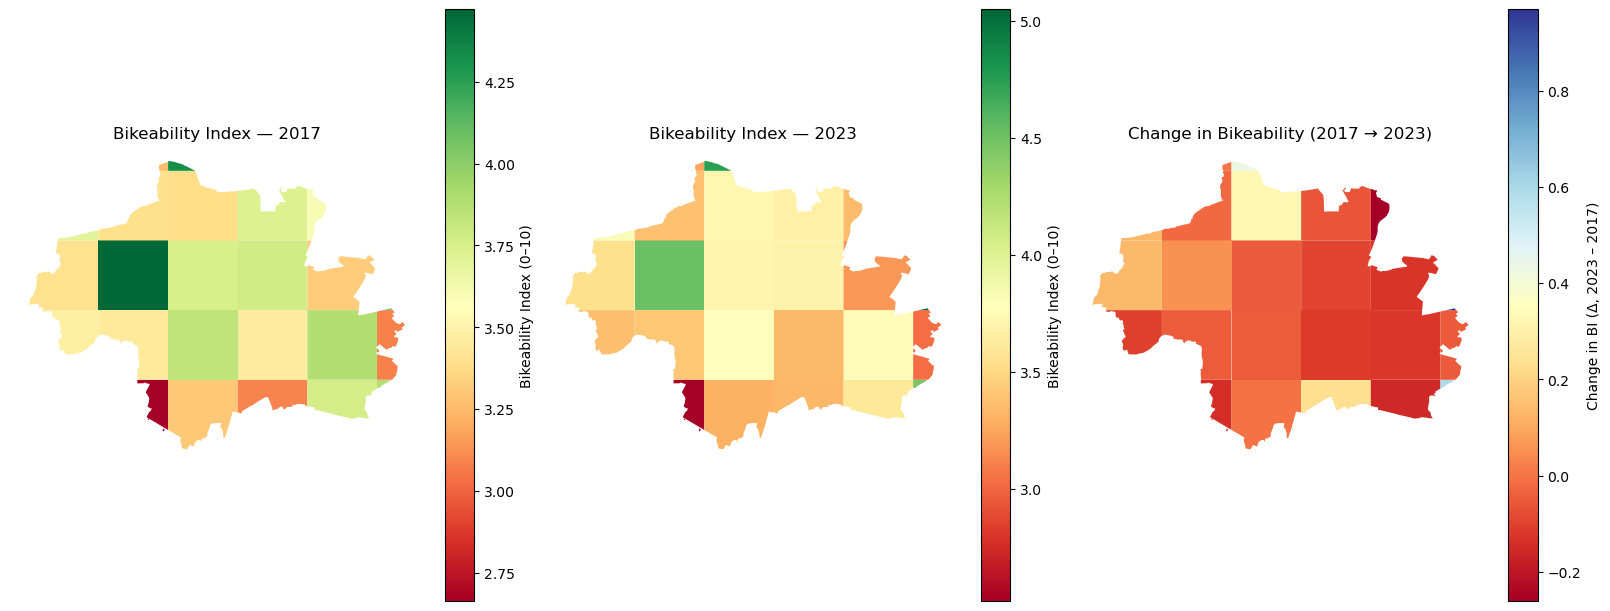

Saved BI maps to: C:\Users\Valeria\OneDrive\Рабочий стол\Thesis\plots\bikeability_index_maps.png


In [73]:
# --- Visualize Bikeability Index (BI) for 2017 & 2023 ---

import yaml
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt

# Load config paths
with open("../config.yml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

THESIS_PATH = Path(cfg["THESIS_PATH"])
RAW_DIR  = THESIS_PATH / "Data" / "00_raw_data" / "Munich"
PLOTS    = THESIS_PATH / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

GPKG = RAW_DIR / "munich_bikeability_raw.gpkg"

# Load BI layers for both years
g2017 = gpd.read_file(GPKG, layer="grid5k_2017_BI")
g2023 = gpd.read_file(GPKG, layer="grid5k_2023_BI")

# Compute change map (ΔBI = 2023 – 2017)
delta = g2023[["cell_id", "geometry", "score_BI"]].merge(
    g2017[["cell_id", "score_BI"]],
    on="cell_id",
    suffixes=("_2023", "_2017")
)
delta["delta_BI"] = delta["score_BI_2023"] - delta["score_BI_2017"]

# --- Plot setup ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

# 2017
g2017.plot(
    column="score_BI", ax=axes[0],
    cmap="RdYlGn", legend=True,
    legend_kwds={"label": "Bikeability Index (0–10)"},
    edgecolor="none"
)
axes[0].set_title("Bikeability Index — 2017")
axes[0].axis("off")

# 2023
g2023.plot(
    column="score_BI", ax=axes[1],
    cmap="RdYlGn", legend=True,
    legend_kwds={"label": "Bikeability Index (0–10)"},
    edgecolor="none"
)
axes[1].set_title("Bikeability Index — 2023")
axes[1].axis("off")

# Change map (2023 – 2017)
delta.plot(
    column="delta_BI", ax=axes[2],
    cmap="RdYlBu", legend=True,
    legend_kwds={"label": "Change in BI (Δ, 2023 – 2017)"},
    edgecolor="none"
)
axes[2].set_title("Change in Bikeability (2017 → 2023)")
axes[2].axis("off")

# Save figure
out_path = PLOTS / "bikeability_index_maps.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved BI maps to:", out_path)
